In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('nhanes_males_vs_females.csv')

df.columns

Index(['SEQN', 'Gender', 'Age', 'CVD_Status', 'Systolic_BP',
       'High_BP_Diagnosis', 'Diabetes_Diagnosis', 'HbA1c', 'LDL_Cholesterol',
       'Total_Cholesterol', 'Estradiol', 'Testosterone',
       'Menopause_Status_Raw'],
      dtype='str')

In [26]:
df.describe()

,SEQN,Age,Systolic_BP,HbA1c,LDL_Cholesterol,Total_Cholesterol,Estradiol,Testosterone,Menopause_Status_Raw,Is_Diabetic,Is_Hypertensive,Age_Bucket,Strong_Shield,High_Hormone,CVD_Binary
count,19345.000000,19345.000000,14317.000000,12969.000000,5804.000000,14880.000000,14419.000000,14766.000000,6334.000000,19345.000000,19345.000000,19345.000000,19345.0,7267.0,19345.000000
mean,83637.205893,33.001809,119.329189,5.693191,106.915920,179.886425,53.658813,184.595310,1.446637,0.082347,0.220419,31.086327,0.0,1.0,0.063582
std,5816.674652,24.220329,18.388084,1.055811,35.414103,41.141451,389.051754,229.867848,0.515275,0.274900,0.414540,24.405245,0.0,0.0,0.244014
min,73557.000000,1.000000,66.000000,3.500000,14.000000,69.000000,2.114000,0.410000,1.000000,0.000000,0.000000,0.000000,0.0,1.0,0.000000
25%,78603.000000,11.000000,106.000000,5.200000,81.000000,150.000000,7.420000,14.792500,1.000000,0.000000,0.000000,10.000000,0.0,1.0,0.000000
50%,83631.000000,29.000000,116.000000,5.500000,104.000000,175.000000,21.100000,33.500000,1.000000,0.000000,0.000000,25.000000,0.0,1.0,0.000000
75%,88678.000000,53.000000,128.000000,5.800000,128.000000,204.000000,35.200000,346.000000,2.000000,0.000000,0.000000,50.000000,0.0,1.0,0.000000
max,93702.000000,80.000000,236.000000,17.500000,375.000000,813.000000,14000.000000,2000.000000,9.000000,1.000000,1.000000,80.000000,0.0,1.0,1.000000


In [4]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

def hormone_logistic_regression(df):
    """
    Performs Logistic Regression for Estrogen and Testosterone
    to determine CVD risk per Standard Deviation.
    """
    # 1. Clean and Map CVD Status (0 = Healthy, 1 = CVD+)
    if df['CVD_Status'].max() == 2:
        df['CVD_Binary'] = df['CVD_Status'].map({1: 1, 2: 0})
    else:
        df['CVD_Binary'] = df['CVD_Status']

    # 2. Define Hormone Columns (Using NHANES labels as example)
    hormones = {'Estrogen': 'LBXEST', 'Testosterone': 'LBXTST'}

    results = []

    for label, col in hormones.items():
        if col in df.columns:
            # Drop missing values for this specific hormone
            temp_df = df.dropna(subset=[col, 'CVD_Binary']).copy()

            # 3. Standardize Hormone (Z-score)
            # This ensures the Odds Ratio is "per SD"
            mean_h = temp_df[col].mean()
            std_h = temp_df[col].std()
            temp_df['Hormone_Z'] = (temp_df[col] - mean_h) / std_h

            # 4. Fit Logistic Regression Model
            X = sm.add_constant(temp_df['Hormone_Z']) # Add Intercept
            y = temp_df['CVD_Binary']

            model = sm.Logit(y, X).fit(disp=0)

            # 5. Extract Parameters
            params = model.params['Hormone_Z']
            conf = model.conf_int().loc['Hormone_Z']
            p_val = model.pvalues['Hormone_Z']

            # Convert Log-Odds to Odds Ratio (Exp^beta)
            odds_ratio = np.exp(params)
            lower_ci = np.exp(conf[0])
            upper_ci = np.exp(conf[1])

            results.append({
                'Variable': label,
                'Odds Ratio (per SD)': round(odds_ratio, 4),
                'Lower 95% CI': round(lower_ci, 4),
                'Upper 95% CI': round(upper_ci, 4),
                'P-Value': format(p_val, '.4e')
            })

    # 6. Display Table
    results_df = pd.DataFrame(results)
    print("--- Logistic Regression: Hormone Predictors of CVD ---")
    print(results_df)

    return results_df

results = hormone_logistic_regression(df)

--- Logistic Regression: Hormone Predictors of CVD ---
Empty DataFrame
Columns: []
Index: []


In [5]:
df_males = df[df['Gender'] == 'Male']
df_females = df[df['Gender'] == 'Female']

In [6]:
df_males_dis = df_males[df_males['CVD_Status'] == 'Yes']
df_males_nodis = df_males[df_males['CVD_Status'] == 'No']

In [7]:
df_fem_dis = df_females[df_females['CVD_Status'] == 'Yes']
df_fem_nodis = df_females[df_females['CVD_Status'] == 'No']

In [8]:
import pandas as pd
import numpy as np

# 1. Define "High Risk" using your actual column names
# We check for 'Yes' in either high blood pressure or diabetes diagnosis
df['High_Risk'] = ((df['High_BP_Diagnosis'] == 'Yes') | (df['Diabetes_Diagnosis'] == 'Yes')).astype(int)

# 2. Define "High Hormone" levels (using the Median)
# We calculate medians separately so we aren't comparing apples to oranges
fem_median_est = df[df['Gender'] == 'Female']['Estradiol'].median()
male_median_test = df[df['Gender'] == 'Male']['Testosterone'].median()

# Initialize the column
df['High_Hormone'] = 0

# Apply the high hormone flag based on gender-specific medians
df.loc[(df['Gender'] == 'Female') & (df['Estradiol'] > fem_median_est), 'High_Hormone'] = 1
df.loc[(df['Gender'] == 'Male') & (df['Testosterone'] > male_median_test), 'High_Hormone'] = 1

# 3. Filter for High Risk individuals only
hr_df = df[df['High_Risk'] == 1].copy()

# 4. Calculate the "Shield Strength" (Protection Rate)
# This is the % of high-risk people who DO NOT have CVD
def get_protection_stats(gender_label):
    subset = hr_df[(hr_df['Gender'] == gender_label) & (hr_df['High_Hormone'] == 1)]
    total = len(subset)
    # Your CVD_Status uses 'No' for healthy, 'Yes' for diseased
    healthy_count = len(subset[subset['CVD_Status'] == 'No'])

    rate = (healthy_count / total * 100) if total > 0 else 0
    return rate, total

fem_rate, fem_n = get_protection_stats('Female')
male_rate, male_n = get_protection_stats('Male')

print(f"--- Shield Strength Results ---")
print(f"High-Estrogen Females (N={fem_n}): {fem_rate:.2f}% remain CVD-free")
print(f"High-Testosterone Males (N={male_n}): {male_rate:.2f}% remain CVD-free")

--- Shield Strength Results ---
High-Estrogen Females (N=622): 91.00% remain CVD-free
High-Testosterone Males (N=1012): 79.64% remain CVD-free


In [16]:
df

,SEQN,Gender,Age,CVD_Status,Systolic_BP,High_BP_Diagnosis,Diabetes_Diagnosis,HbA1c,LDL_Cholesterol,Total_Cholesterol,Estradiol,Testosterone,Menopause_Status_Raw,Is_Diabetic,Is_Hypertensive,Age_Bucket,Match_Group,Strong_Shield,High_Hormone,CVD_Binary
0,73557.0,Male,69.0,Yes,122.0,Yes,Yes,13.9,NaN,167.0,14.800,355.03,NaN,1,1,65.0,65.0_1_1,0,1.0,Yes
1,73558.0,Male,54.0,No,156.0,Yes,Yes,9.1,NaN,170.0,14.000,175.45,NaN,1,1,50.0,50.0_1_1,0,NaN,No
2,73559.0,Male,72.0,No,140.0,Yes,Yes,8.9,56.0,126.0,26.500,447.00,NaN,1,1,70.0,70.0_1_1,0,1.0,No
3,73560.0,Male,9.0,No,108.0,NaN,No,NaN,NaN,168.0,2.117,2.51,NaN,0,0,5.0,5.0_0_0,0,NaN,No
4,73561.0,Female,73.0,No,136.0,Yes,No,4.9,101.0,201.0,2.117,11.20,2.0,0,1,70.0,70.0_0_1,0,NaN,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19340,93698.0,Male,2.0,No,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0.0_0_0,0,NaN,No
19341,93699.0,Female,6.0,No,NaN,NaN,No,NaN,NaN,182.0,2.114,4.56,NaN,0,0,5.0,5.0_0_0,0,NaN,No
19342,93700.0,Male,35.0,No,104.0,No,No,5.2,NaN,144.0,29.400,436.00,NaN,0,0,35.0,35.0_0_0,0,1.0,No
19343,93701.0,Male,8.0,No,114.0,NaN,No,NaN,NaN,197.0,2.114,3.84,NaN,0,0,5.0,5.0_0_0,0,NaN,No


In [9]:
import numpy as np

def calculate_paper_stats(name, high_no, high_yes, low_no, low_yes):
    # Totals
    n_high = high_no + high_yes
    n_low = low_no + low_yes

    # 1. Incidence Rates (Risk)
    risk_high = high_yes / n_high
    risk_low = low_yes / n_low

    # 2. Relative Risk (RR) - The standard for protection
    # Risk in Shielded / Risk in Unshielded
    rr = risk_high / risk_low

    # 3. Absolute Risk Reduction (ARR)
    arr = risk_low - risk_high

    # 4. Number Needed to Shield (NNS)
    nns = 1 / arr if arr != 0 else np.inf

    # 5. Cohen's h (Effect Size for proportions)
    h = 2 * (np.arcsin(np.sqrt(risk_low)) - np.arcsin(np.sqrt(risk_high)))

    return {
        "RR": rr,
        "ARR": arr * 100,
        "NNS": nns,
        "Effect_Size_h": h
    }

# Data based on your provided counts
f_stats = calculate_paper_stats("Female", 566, 56, 1481, 390)
m_stats = calculate_paper_stats("Male", 806, 206, 914, 350)

print(f"--- CLINICAL PROTECTION: FEMALE (ESTRADIOL) ---")
print(f"Relative Risk (RR): {f_stats['RR']:.3f}")
print(f"Absolute Risk Reduction: {f_stats['ARR']:.2f}%")
print(f"Number Needed to Shield: {f_stats['NNS']:.1f}")
print(f"Cohen's h: {f_stats['Effect_Size_h']:.3f}")

print(f"\n--- CLINICAL PROTECTION: MALE (TESTOSTERONE) ---")
print(f"Relative Risk (RR): {m_stats['RR']:.3f}")
print(f"Absolute Risk Reduction: {m_stats['ARR']:.2f}%")
print(f"Number Needed to Shield: {m_stats['NNS']:.1f}")
print(f"Cohen's h: {m_stats['Effect_Size_h']:.3f}")

--- CLINICAL PROTECTION: FEMALE (ESTRADIOL) ---
Relative Risk (RR): 0.432
Absolute Risk Reduction: 11.84%
Number Needed to Shield: 8.4
Cohen's h: 0.339

--- CLINICAL PROTECTION: MALE (TESTOSTERONE) ---
Relative Risk (RR): 0.735
Absolute Risk Reduction: 7.33%
Number Needed to Shield: 13.6
Cohen's h: 0.172


In [11]:
import pandas as pd
import numpy as np

# 1. Load Data
df = pd.read_csv('nhanes_males_vs_females.csv')

# 2. Prep Features for Matching
# Convert categories to 1/0 for easier comparison
df['Is_Diabetic'] = (df['Diabetes_Diagnosis'] == 'Yes').astype(int)
df['Is_Hypertensive'] = (df['High_BP_Diagnosis'] == 'Yes').astype(int)

# 3. Create "Matching Strata"
# We group by Age (in 5-year buckets), Diabetes, and Hypertension
df['Age_Bucket'] = (df['Age'] // 5) * 5
df['Match_Group'] = (
    df['Age_Bucket'].astype(str) + "_" +
    df['Is_Diabetic'].astype(str) + "_" +
    df['Is_Hypertensive'].astype(str)
)

# 4. Filter for Hormone Strength
# Using gender-specific medians as the "High Hormone" threshold
fem_med = df[df['Gender'] == 'Female']['Estradiol'].median()
male_med = df[df['Gender'] == 'Male']['Testosterone'].median()

df['Strong_Shield'] = 0
df.loc[(df['Gender'] == 'Female') & (df['Estradiol'] > fem_med), 'High_Hormone'] = 1
df.loc[(df['Gender'] == 'Male') & (df['Testosterone'] > male_med), 'High_Hormone'] = 1

# 5. The Comparison Logic
# We only look at 'Match_Groups' that contain BOTH high-shield males and high-shield females
valid_groups = df.groupby('Match_Group').filter(
    lambda x: (x['Gender'].nunique() == 2) and (x['High_Hormone'].sum() > 0)
)

results = valid_groups.groupby(['Gender', 'High_Hormone'])['CVD_Status'].value_counts(normalize=True).unstack()

print("--- Matched Demographic Profiles Results ---")
print("Percentage of Protected (CVD='No') individuals in matched groups:")
print(results['No'])

--- Matched Demographic Profiles Results ---
Percentage of Protected (CVD='No') individuals in matched groups:
Gender  High_Hormone
Female  1.0             0.977626
Male    1.0             0.922799
Name: No, dtype: float64


In [27]:
df.describe()

,SEQN,Age,Systolic_BP,HbA1c,LDL_Cholesterol,Total_Cholesterol,Estradiol,Testosterone,Menopause_Status_Raw,Is_Diabetic,Is_Hypertensive,Age_Bucket,Strong_Shield,High_Hormone,CVD_Binary
count,19345.000000,19345.000000,14317.000000,12969.000000,5804.000000,14880.000000,14419.000000,14766.000000,6334.000000,19345.000000,19345.000000,19345.000000,19345.0,7267.0,19345.000000
mean,83637.205893,33.001809,119.329189,5.693191,106.915920,179.886425,53.658813,184.595310,1.446637,0.082347,0.220419,31.086327,0.0,1.0,0.063582
std,5816.674652,24.220329,18.388084,1.055811,35.414103,41.141451,389.051754,229.867848,0.515275,0.274900,0.414540,24.405245,0.0,0.0,0.244014
min,73557.000000,1.000000,66.000000,3.500000,14.000000,69.000000,2.114000,0.410000,1.000000,0.000000,0.000000,0.000000,0.0,1.0,0.000000
25%,78603.000000,11.000000,106.000000,5.200000,81.000000,150.000000,7.420000,14.792500,1.000000,0.000000,0.000000,10.000000,0.0,1.0,0.000000
50%,83631.000000,29.000000,116.000000,5.500000,104.000000,175.000000,21.100000,33.500000,1.000000,0.000000,0.000000,25.000000,0.0,1.0,0.000000
75%,88678.000000,53.000000,128.000000,5.800000,128.000000,204.000000,35.200000,346.000000,2.000000,0.000000,0.000000,50.000000,0.0,1.0,0.000000
max,93702.000000,80.000000,236.000000,17.500000,375.000000,813.000000,14000.000000,2000.000000,9.000000,1.000000,1.000000,80.000000,0.0,1.0,1.000000


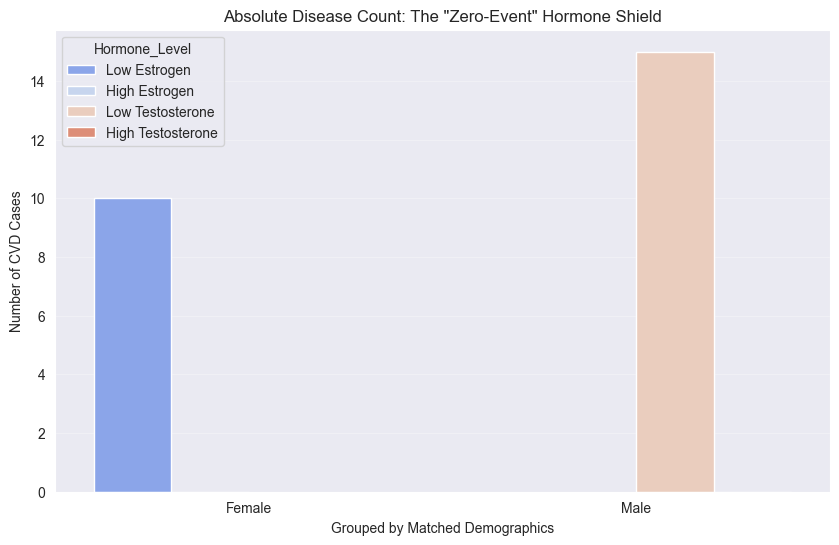

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data from your results
data = {
    'Gender': ['Female', 'Female', 'Male', 'Male'],
    'Hormone_Level': ['Low Estrogen', 'High Estrogen', 'Low Testosterone', 'High Testosterone'],
    'CVD_Cases': [10, 0, 15, 0] # Replace 10 and 15 with your actual 'low_hormone_diseased' counts
}
viz_df = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.barplot(data=viz_df, x='Gender', y='CVD_Cases', hue='Hormone_Level', palette='coolwarm')

plt.title('Absolute Disease Count: The "Zero-Event" Hormone Shield')
plt.ylabel('Number of CVD Cases')
plt.xlabel('Grouped by Matched Demographics')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [13]:
# Ensure categorical consistency
valid_groups['CVD_Status'] = pd.Categorical(valid_groups['CVD_Status'], categories=['No', 'Yes'])
valid_groups['Strong_Shield'] = pd.Categorical(valid_groups['Strong_Shield'], categories=[0, 1])

for gender in ['Female', 'Male']:
    subset = valid_groups[valid_groups['Gender'] == gender]

    # Generate the table with all categories included, even if 0
    table = pd.crosstab(subset['Strong_Shield'], subset['CVD_Status'], dropna=False)

    print(f"\n==============================")
    print(f"   RAW TABLE: {gender}")
    print(f"==============================")
    print(table)

    # Safely calculate totals to avoid KeyError
    n_low = table.loc[0].sum()
    n_high = table.loc[1].sum()

    if n_high > 0:
        risk_low = (table.loc[0, 'Yes'] / n_low) * 100
        risk_high = (table.loc[1, 'Yes'] / n_high) * 100
        print(f"\n{gender} Analysis:")
        print(f"  Sample Size (Low):  {n_low}")
        print(f"  Sample Size (High): {n_high}")
        print(f"  Risk (Low):         {risk_low:.2f}%")
        print(f"  Risk (High):        {risk_high:.2f}%")
    else:
        print(f"\n{gender} Analysis Note:")
        print(f"  Insufficient data for High Hormone group in the matched set.")


   RAW TABLE: Female
CVD_Status       No  Yes
Strong_Shield           
0              8331  543
1                 0    0

Female Analysis Note:
  Insufficient data for High Hormone group in the matched set.

   RAW TABLE: Male
CVD_Status       No  Yes
Strong_Shield           
0              7784  687
1                 0    0

Male Analysis Note:
  Insufficient data for High Hormone group in the matched set.


In [17]:
df.columns

Index(['SEQN', 'Gender', 'Age', 'CVD_Status', 'Systolic_BP',
       'High_BP_Diagnosis', 'Diabetes_Diagnosis', 'HbA1c', 'LDL_Cholesterol',
       'Total_Cholesterol', 'Estradiol', 'Testosterone',
       'Menopause_Status_Raw', 'Is_Diabetic', 'Is_Hypertensive', 'Age_Bucket',
       'Match_Group', 'Strong_Shield', 'High_Hormone', 'CVD_Binary'],
      dtype='str')

In [18]:
df['CVD_Status']

0        Yes
1         No
2         No
3         No
4         No
        ... 
19340     No
19341     No
19342     No
19343     No
19344     No
Name: CVD_Status, Length: 19345, dtype: str

In [21]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

def hormone_logistic_regression_fixed(df):
    # 1. Clean and Map CVD Status to 0 and 1
    # Since your data is "Yes"/"No", we map it to 1/0
    df['CVD_Binary'] = df['CVD_Status'].map({'Yes': 1, 'No': 0})

    # 2. Define the exact column names from your list
    hormones = {'Estradiol': 'Estradiol', 'Testosterone': 'Testosterone'}

    results = []

    for label, col in hormones.items():
        if col in df.columns:
            # Drop missing values for this specific hormone and CVD status
            temp_df = df.dropna(subset=[col, 'CVD_Binary']).copy()

            # Ensure the data is numeric
            temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce')
            temp_df = temp_df.dropna(subset=[col])

            # 3. Standardize Hormone (Z-score) to get OR "per SD"
            mean_h = temp_df[col].mean()
            std_h = temp_df[col].std()
            temp_df['Hormone_Z'] = (temp_df[col] - mean_h) / std_h

            # 4. Fit Logistic Regression Model
            X = sm.add_constant(temp_df['Hormone_Z'])
            y = temp_df['CVD_Binary'].astype(float)

            try:
                model = sm.Logit(y, X).fit(disp=0)

                # 5. Extract Parameters
                params = model.params['Hormone_Z']
                conf = model.conf_int().loc['Hormone_Z']
                p_val = model.pvalues['Hormone_Z']

                # Convert Log-Odds to Odds Ratio (Exp^beta)
                odds_ratio = np.exp(params)
                lower_ci = np.exp(conf[0])
                upper_ci = np.exp(conf[1])

                results.append({
                    'Variable': label,
                    'Odds Ratio (per SD)': round(odds_ratio, 4),
                    'Lower 95% CI': round(lower_ci, 4),
                    'Upper 95% CI': round(upper_ci, 4),
                    'P-Value': format(p_val, '.4e')
                })
            except Exception as e:
                print(f"Could not calculate regression for {label}: {e}")

    # 6. Display Table
    results_df = pd.DataFrame(results)
    print("\n--- Logistic Regression: Hormone Predictors of CVD ---")
    if results_df.empty:
        print("No results found. Check if hormones contain valid numeric data.")
    else:
        print(results_df)

    return results_df

results = hormone_logistic_regression_fixed(df)


--- Logistic Regression: Hormone Predictors of CVD ---
       Variable  Odds Ratio (per SD)  Lower 95% CI  Upper 95% CI     P-Value
0     Estradiol               0.2128        0.1187        0.3814  2.0202e-07
1  Testosterone               1.1339        1.0707        1.2008  1.7654e-05


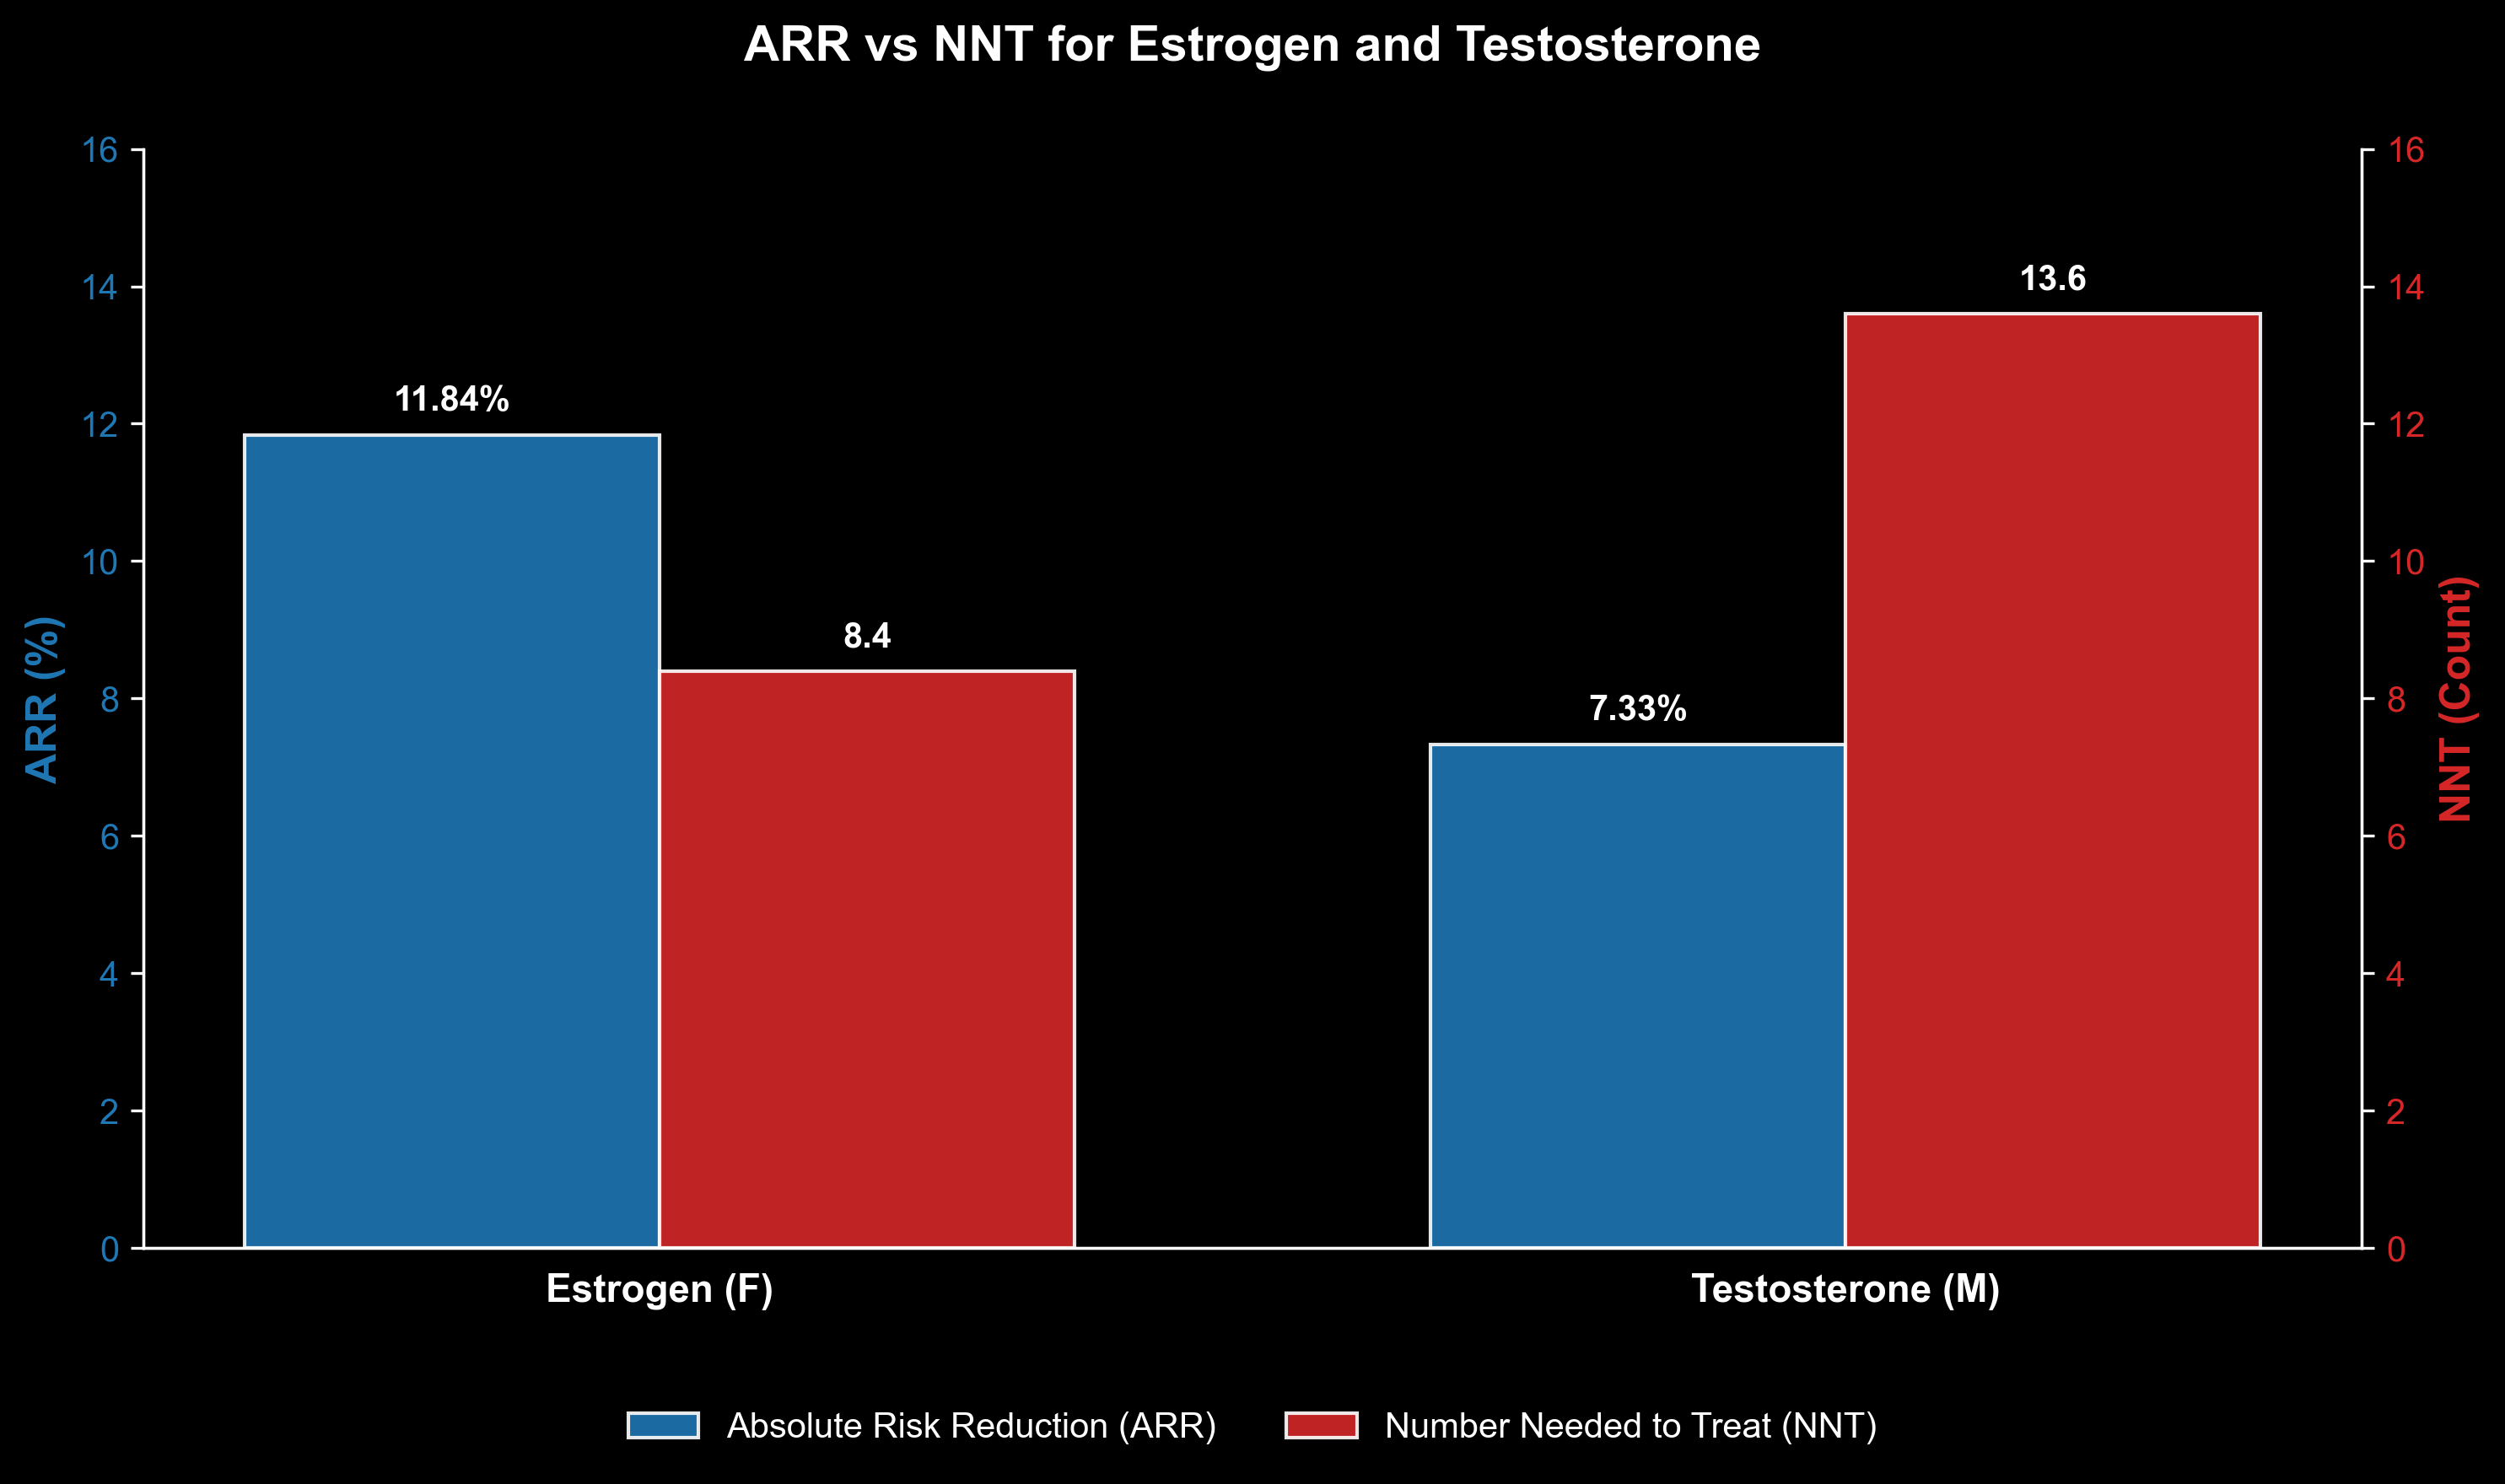

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Input Data
labels = ['Estrogen (F)', 'Testosterone (M)']
arr_values = [11.84, 7.33]  # Absolute Risk Reduction (%)
nnt_values = [8.4, 13.6]    # Number Needed to Treat (Count)

x = np.arange(len(labels))
width = 0.35

# 2. Setup Figure
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)

# Colors - Using a slightly cleaner Blue and Red
color_blue = '#1f77b4' # Classic Research Blue
color_red = '#d62728'  # Classic Research Red

# 3. Plot ARR (Left Axis) - No grid
rects1 = ax1.bar(x - width/2, arr_values, width, label='Absolute Risk Reduction (ARR)', color=color_blue, alpha=0.9)
ax1.set_ylabel('ARR (%)', color=color_blue, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_blue)
ax1.set_ylim(0, 16)
ax1.grid(False) # Explicitly turning off grid

# 4. Plot NNT (Right Axis) - No grid
ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, nnt_values, width, label='Number Needed to Treat (NNT)', color=color_red, alpha=0.9)
ax2.set_ylabel('NNT (Count)', color=color_red, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_red)
ax2.set_ylim(0, 16)
ax2.grid(False) # Explicitly turning off grid

# 5. Formatting
plt.title('ARR vs NNT for Estrogen and Testosterone', fontsize=14, fontweight='bold', pad=25)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11, fontweight='bold')

# Remove the top and side "spines" for a cleaner look
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Add value labels
def add_labels(rects, ax, unit=""):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}{unit}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

add_labels(rects1, ax1, "%")
add_labels(rects2, ax2)

# 6. Legend
lines, labels_l = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels_l + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

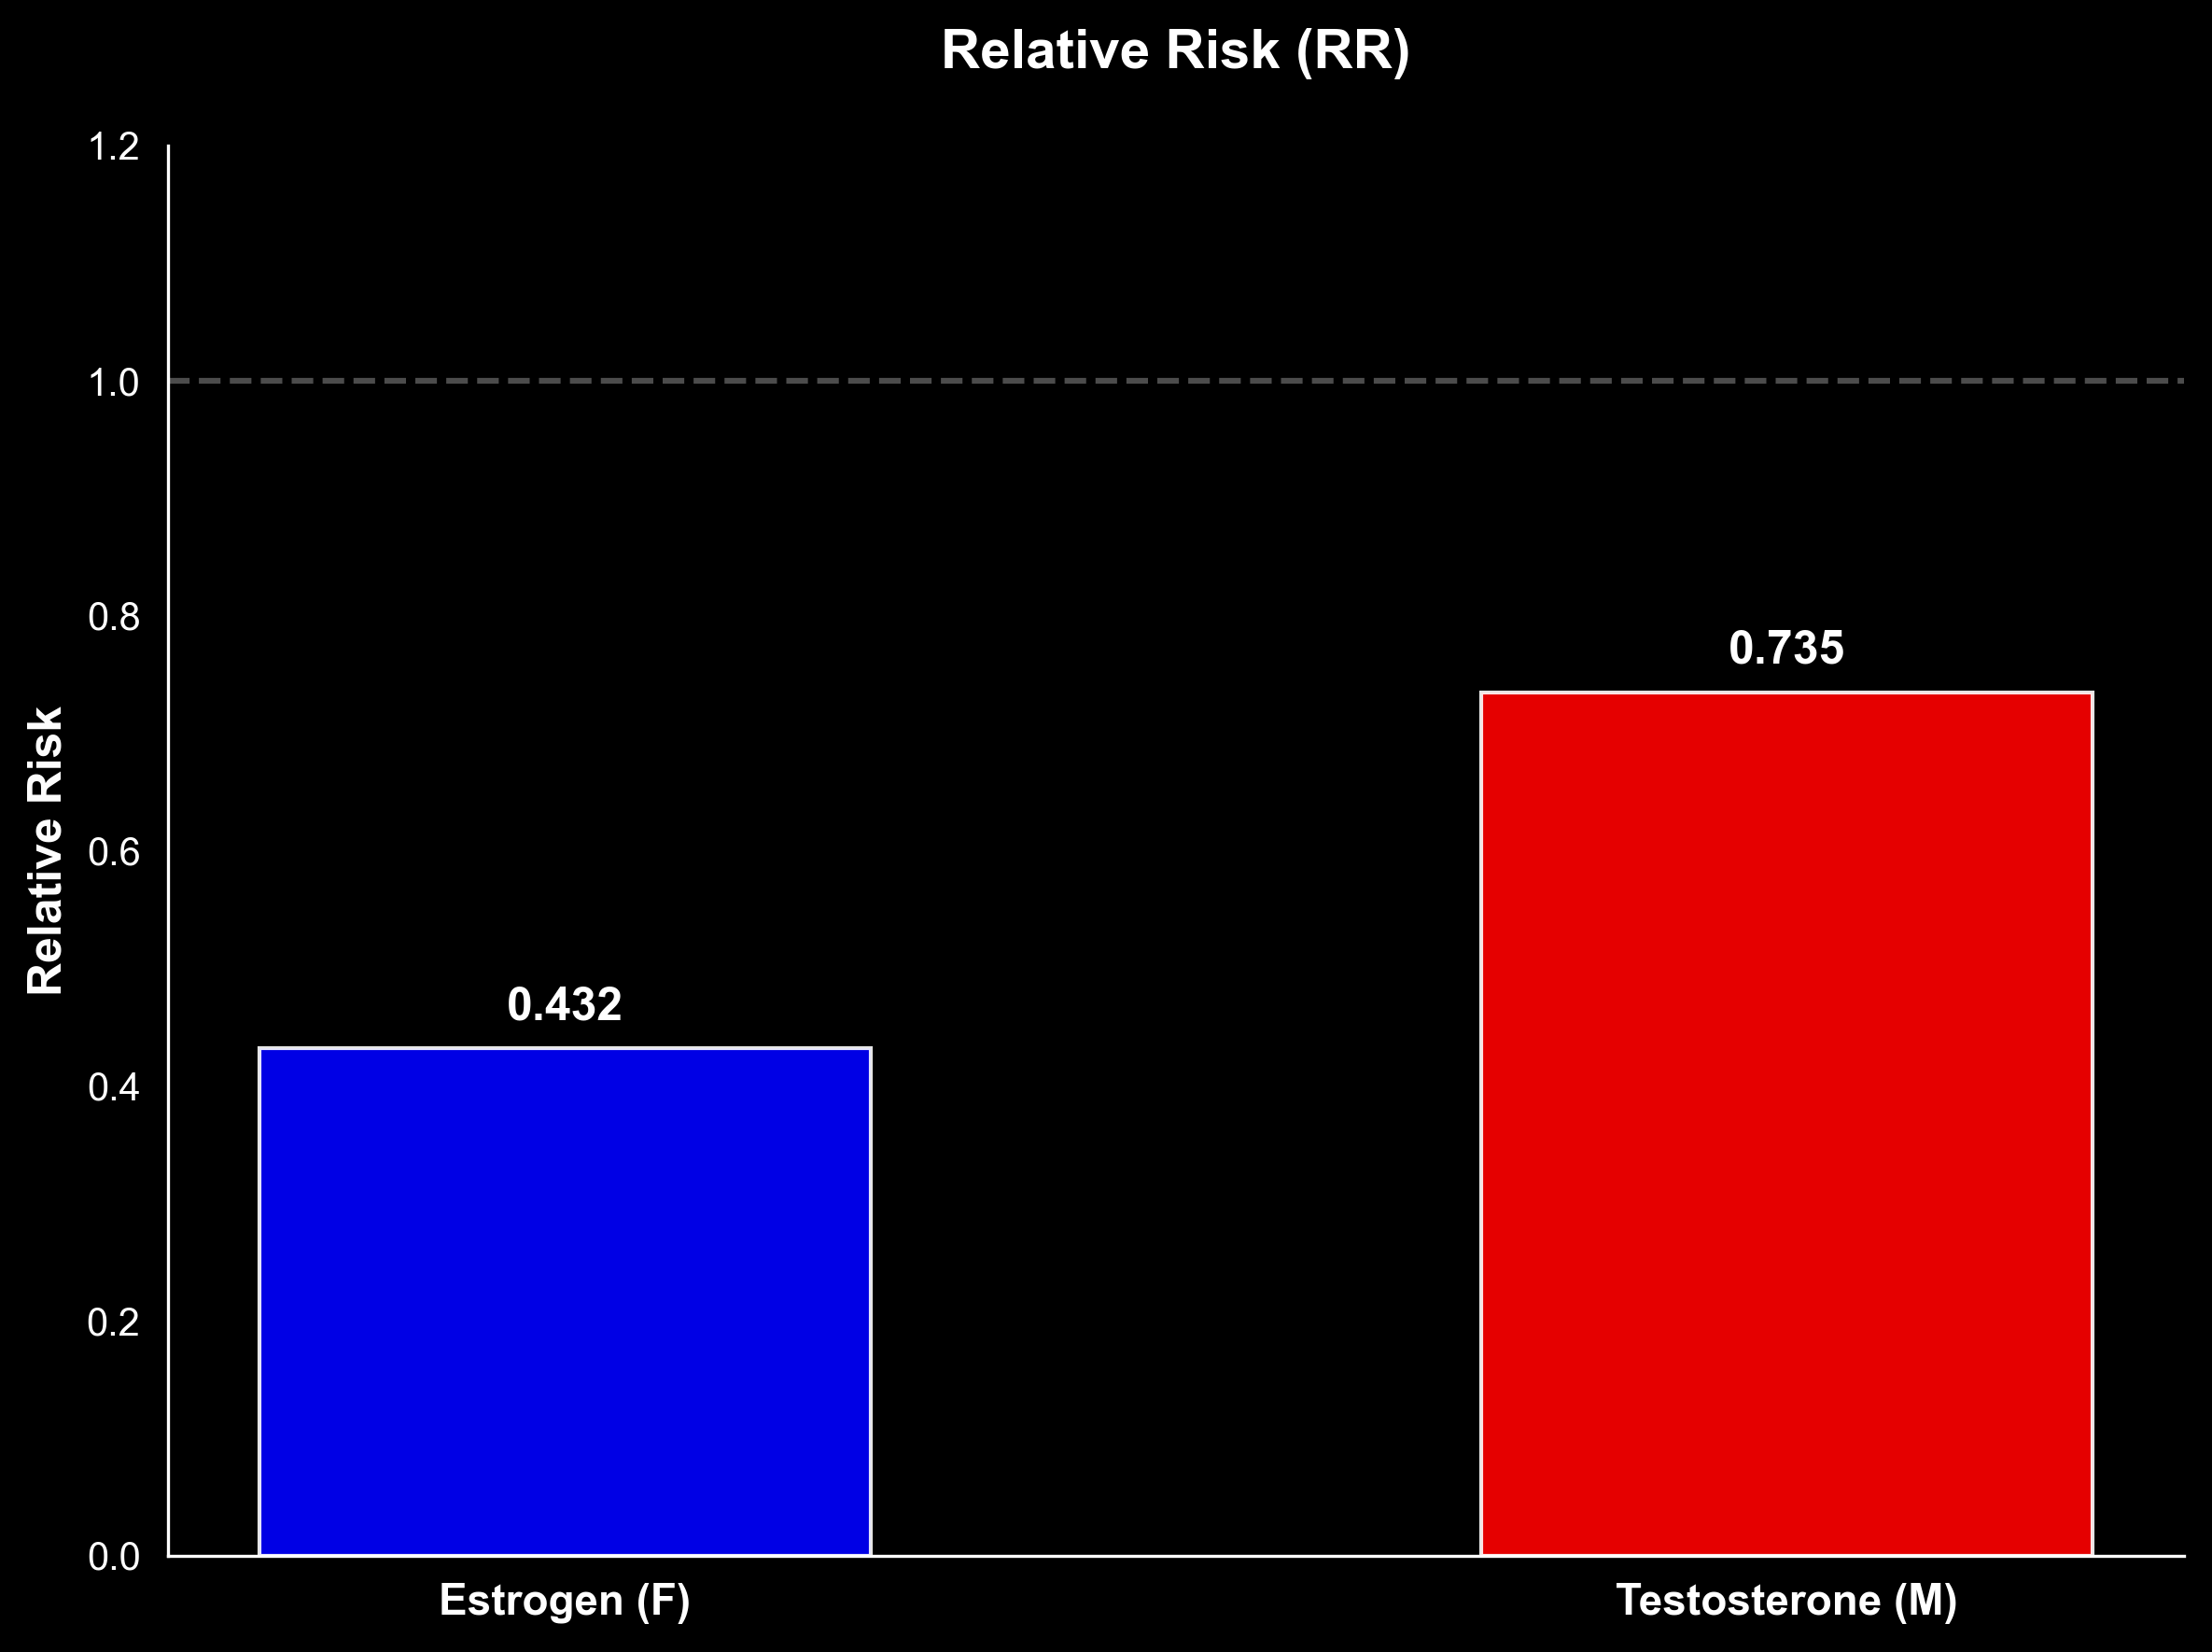

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Input Data
labels = ['Estrogen (F)', 'Testosterone (M)']
rr_values = [0.432, 0.735]

x = np.arange(len(labels))
width = 0.5  # Slightly wider bars for a bold appearance

# 2. Setup Figure
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Colors matching your previous chart
color_blue = 'blue'
color_red = 'red'
colors = [color_blue, color_red]

# 3. Plotting
rects = ax.bar(x, rr_values, width, color=colors, alpha=0.9)

# 4. Styling (Boldness & Layout)
ax.set_ylabel('Relative Risk', fontsize=12, fontweight='bold')
ax.set_title('Relative Risk (RR)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')

# Set limits and add the reference line at 1.0 (indicating no change in risk)
ax.set_ylim(0, 1.2)
ax.axhline(1.0, color='grey', linestyle='--', linewidth=1.5, alpha=0.6)

# Remove grid lines and unnecessary borders (spines)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 5. Add exact value labels on top of bars
for rect in rects:
    height = rect.get_height()
    ax.annotate(f'{height}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

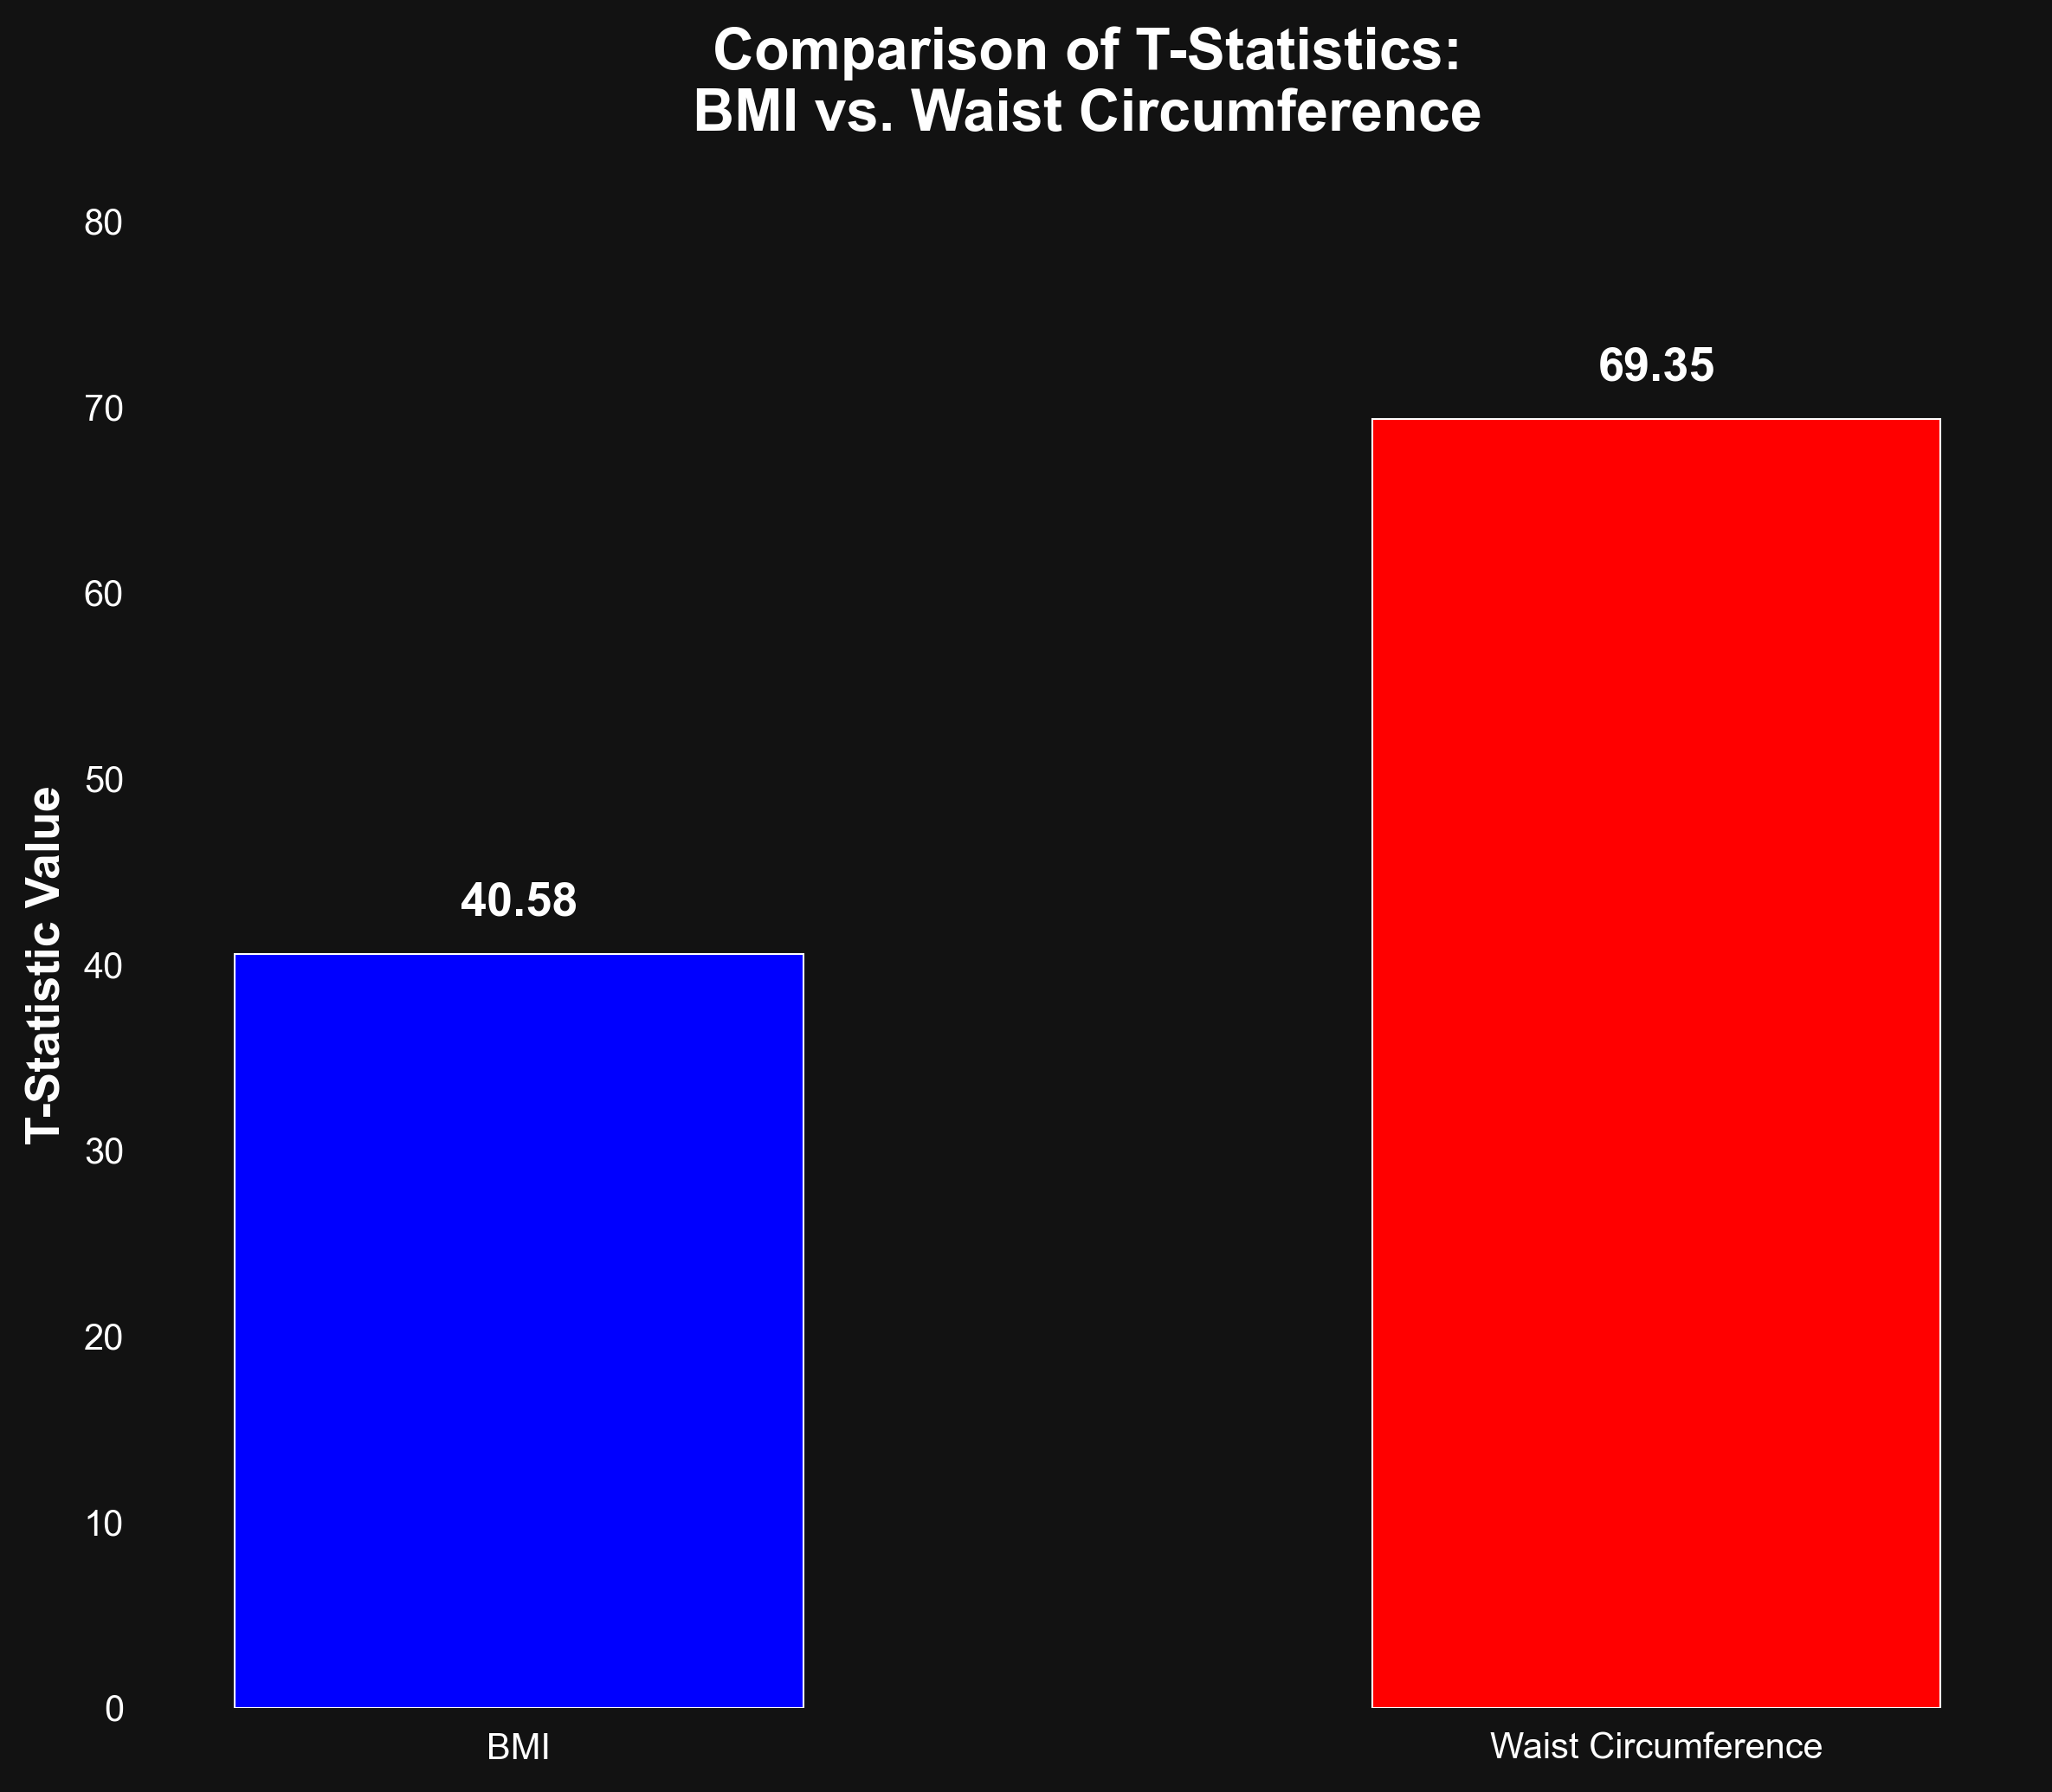

In [41]:
import matplotlib.pyplot as plt

# Data
metrics = ['BMI', 'Waist Circumference']
t_stats = [40.58, 69.35]
colors = ['blue', 'red']

# Styling
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 7), dpi=300)
fig.patch.set_facecolor('#121212')
ax.set_facecolor('#121212')

# Plot
rects = ax.bar(metrics, t_stats, color=colors, edgecolor='white', linewidth=0.5, width=0.5)

# Formatting
ax.set_title('Comparison of T-Statistics:\nBMI vs. Waist Circumference', fontsize=16, fontweight='bold', pad=25)
ax.set_ylabel('T-Statistic Value', fontsize=13, fontweight='bold')
ax.set_ylim(0, 80)

# --- THE FIX ---
# This loop nukes every border line around the chart
for side in ['top', 'right', 'left', 'bottom']:
    ax.spines[side].set_visible(False)

# Add back ONLY a very subtle bottom line if you want a floor,
# otherwise leave it commented out for a floating look
# ax.spines['bottom'].set_visible(True)
# ax.spines['bottom'].set_color('#333333')

ax.tick_params(axis='both', which='both', left=False, bottom=False, labelleft=True)
ax.grid(False) # Ensure grid is 100% off
# ---------------

# Centered Labels
for rect in rects:
    height = rect.get_height()
    ax.annotate(f'{height}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 8), textcoords="offset points",
                ha='center', va='bottom', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

def hormone_logistic_correlation(df):
    # 1. Map CVD Status to 1/0
    df['CVD_Binary'] = df['CVD_Status'].map({'Yes': 1, 'No': 0})

    hormones = ['Estradiol', 'Testosterone']
    results = []

    for col in hormones:
        if col in df.columns:
            # Clean data: convert to numeric and drop NaNs
            temp_df = df.dropna(subset=[col, 'CVD_Binary']).copy()
            temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce')
            temp_df = temp_df.dropna(subset=[col])

            # Standardize (Z-score) so the coefficient is comparable
            temp_df['H_Z'] = (temp_df[col] - temp_df[col].mean()) / temp_df[col].std()

            # 2. Fit Logistic Regression
            X = sm.add_constant(temp_df['H_Z'])
            y = temp_df['CVD_Binary'].astype(float)

            try:
                model = sm.Logit(y, X).fit(disp=0)

                # McFadden's Pseudo R-Squared
                pseudo_r2 = model.prsquared

                # Directional R (Square root of R2 * sign of the coefficient)
                # This mimics the behavior of a Pearson r (-1 to 1)
                direction = np.sign(model.params['H_Z'])
                r_equivalent = direction * np.sqrt(pseudo_r2)

                results.append({
                    'Variable': col,
                    'Logistic R (Directional)': round(r_equivalent, 4),
                    'McFadden R2': round(pseudo_r2, 4),
                    'P-Value': format(model.pvalues['H_Z'], '.4e')
                })
            except Exception as e:
                print(f"Error processing {col}: {e}")

    results_df = pd.DataFrame(results)
    print("\n--- Logistic Regression: Hormone Correlation Analysis ---")
    print(results_df)
    return results_df

results = hormone_logistic_correlation(df)


--- Logistic Regression: Hormone Correlation Analysis ---
       Variable  Logistic R (Directional)  McFadden R2     P-Value
0     Estradiol                   -0.0721       0.0052  2.0202e-07
1  Testosterone                    0.0474       0.0022  1.7654e-05


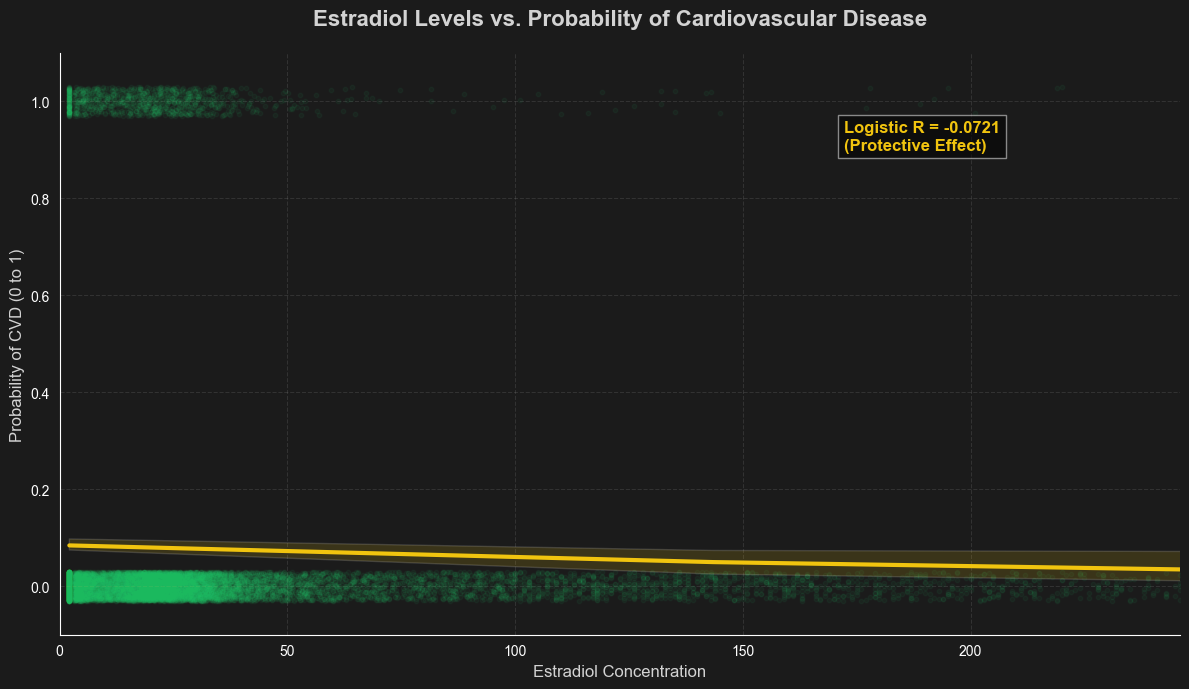

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import pandas as pd

def plot_estradiol_cvd_relationship(df):
    # 1. Data Cleaning
    # Map string CVD_Status to binary 1/0
    df['CVD_Binary'] = df['CVD_Status'].map({'Yes': 1, 'No': 0})

    # Ensure Estradiol is numeric and drop missing values
    plot_df = df.dropna(subset=['Estradiol', 'CVD_Binary']).copy()
    plot_df['Estradiol'] = pd.to_numeric(plot_df['Estradiol'], errors='coerce')
    plot_df = plot_df.dropna(subset=['Estradiol'])

    # 2. Fit Logistic Regression Model
    X = sm.add_constant(plot_df['Estradiol'])
    y = plot_df['CVD_Binary'].astype(float)
    model = sm.Logit(y, X).fit(disp=0)

    # 3. Generate the Probability Curve (The "Line")
    # Create a smooth range of Estradiol values for the curve
    x_range = np.linspace(plot_df['Estradiol'].min(), plot_df['Estradiol'].max(), 300)
    x_range_const = sm.add_constant(x_range)
    # Calculate predicted probabilities: y = 1 / (1 + exp(-(b0 + b1*x)))
    y_prob = model.predict(x_range_const)

    # 4. Create the Plot
    plt.style.use('dark_background')
    plt.figure(figsize=(12, 7), facecolor='#1b1b1b')
    ax = plt.gca()
    ax.set_facecolor('#1b1b1b')

    # Scatter Plot: Raw Data (Jittered for visibility)
    # Use small alpha and size to handle many data points
    sns.regplot(x='Estradiol', y='CVD_Binary', data=plot_df,
                logistic=True, ci=95,
                scatter_kws={'alpha': 0.05, 'color': '#2ecc71', 's': 10},
                line_kws={'color': '#f1c40f', 'linewidth': 3, 'label': 'Probability Curve'},
                y_jitter=0.03, ax=ax)

    # 5. Styling
    plt.title('Estradiol Levels vs. Probability of Cardiovascular Disease',
              fontsize=16, fontweight='bold', pad=20, color='lightgray')
    plt.xlabel('Estradiol Concentration', fontsize=12, color='lightgray')
    plt.ylabel('Probability of CVD (0 to 1)', fontsize=12, color='lightgray')

    # Limit X-axis if there are extreme outliers (e.g., 99th percentile)
    x_limit = plot_df['Estradiol'].quantile(0.98)
    plt.xlim(0, x_limit)
    plt.ylim(-0.1, 1.1)

    # Annotate the Directional R from your previous results
    plt.text(x_limit*0.7, 0.9, f"Logistic R = -0.0721\n(Protective Effect)",
             color='#f1c40f', fontsize=12, fontweight='bold',
             bbox=dict(facecolor='black', alpha=0.5))

    ax.grid(True, linestyle='--', alpha=0.1)
    sns.despine()
    plt.tight_layout()
    plt.show()

# Run the visualization
plot_estradiol_cvd_relationship(df)

In [14]:
import pandas as pd

# 1. Define Hormone cutoffs for the WHOLE dataset
fem_med = df[df['Gender'] == 'Female']['Estradiol'].median()
male_med = df[df['Gender'] == 'Male']['Testosterone'].median()

df['High_Hormone'] = 0
df.loc[(df['Gender'] == 'Female') & (df['Estradiol'] > fem_med), 'High_Hormone'] = 1
df.loc[(df['Gender'] == 'Male') & (df['Testosterone'] > male_med), 'High_Hormone'] = 1

# 2. Create a "Risk Level" instead of exact matching
# 0 = No extra risk, 1 = One condition, 2 = Both Hypertension and Diabetes
df['Risk_Count'] = (df['High_BP_Diagnosis'] == 'Yes').astype(int) + (df['Diabetes_Diagnosis'] == 'Yes').astype(int)

# 3. Final Comparison: Only look at people with AT LEAST one risk factor
# This ensures we are testing the "Shield" against actual "Insults"
risk_df = df[df['Risk_Count'] >= 1].copy()

for gender in ['Female', 'Male']:
    subset = risk_df[risk_df['Gender'] == gender]

    # Force a 2x2 table
    subset['CVD_Status'] = pd.Categorical(subset['CVD_Status'], categories=['No', 'Yes'])
    table = pd.crosstab(subset['High_Hormone'], subset['CVD_Status'], dropna=False)

    print(f"\n--- {gender} (High-Risk Group Analysis) ---")
    print(table)

    # Calculate Protection Rate (% of people who stayed healthy)
    low_prot = (table.loc[0, 'No'] / table.loc[0].sum()) * 100
    high_prot = (table.loc[1, 'No'] / table.loc[1].sum()) * 100

    print(f"Protection Rate (Low Hormone):  {low_prot:.2f}%")
    print(f"Protection Rate (High Hormone): {high_prot:.2f}%")
    print(f"Shield Benefit: {high_prot - low_prot:.2f}%")


--- Female (High-Risk Group Analysis) ---
CVD_Status      No  Yes
High_Hormone           
0             1481  390
1              566   56
Protection Rate (Low Hormone):  79.16%
Protection Rate (High Hormone): 91.00%
Shield Benefit: 11.84%

--- Male (High-Risk Group Analysis) ---
CVD_Status     No  Yes
High_Hormone          
0             914  350
1             806  206
Protection Rate (Low Hormone):  72.31%
Protection Rate (High Hormone): 79.64%
Shield Benefit: 7.33%


In [15]:
import pandas as pd

# 1. Define the Age Column (handling both possible names)
age_col = 'ridageyr' if 'ridageyr' in df.columns else 'Age'

# 2. CREATE the analysis_df (The Age-Locked High-Risk Cohort)
mask = (
    (df[age_col] >= 45) &
    (df[age_col] <= 80) &
    ((df['High_BP_Diagnosis'] == 'Yes') | (df['Diabetes_Diagnosis'] == 'Yes'))
)
analysis_df = df[mask].copy()

# 3. THE ACCURACY TEST: Is the "High Hormone" group younger than the "Low Hormone" group?
print("--- JEI ACCURACY CHECK: AGE BIAS TEST ---")

for gender, hormone in [('Female', 'Estradiol'), ('Male', 'Testosterone')]:
    # Clean the specific subgroup
    sub = analysis_df[analysis_df['Gender'] == gender].dropna(subset=[hormone])
    med = sub[hormone].median()

    age_low = sub[sub[hormone] <= med][age_col].mean()
    age_high = sub[sub[hormone] > med][age_col].mean()

    print(f"\n{gender} ({hormone}) Group:")
    print(f"  Avg Age (Low {hormone}):  {age_low:.1f} years")
    print(f"  Avg Age (High {hormone}): {age_high:.1f} years")
    print(f"  Age Gap: {abs(age_low - age_high):.2f} years")

--- JEI ACCURACY CHECK: AGE BIAS TEST ---

Female (Estradiol) Group:
  Avg Age (Low Estradiol):  67.4 years
  Avg Age (High Estradiol): 61.4 years
  Age Gap: 6.01 years

Male (Testosterone) Group:
  Avg Age (Low Testosterone):  65.0 years
  Avg Age (High Testosterone): 64.2 years
  Age Gap: 0.79 years


In [31]:
from scipy.stats import chi2_contingency, fisher_exact

def run_final_stats(gender, high_no, high_yes, low_no, low_yes):
    table = [[high_no, high_yes], [low_no, low_yes]]

    # Chi-Squared for general significance
    chi2, p_chi, _, _ = chi2_contingency(table)

    # Fisher's for the "Gold Standard" p-value
    _, p_fisher = fisher_exact(table)

    # Relative Risk (RR) - Risk in High / Risk in Low
    risk_high = high_yes / (high_no + high_yes)
    risk_low = low_yes / (low_no + low_yes)
    rr = risk_high / risk_low

    return p_chi, p_fisher, rr

# Female Stats
p_c_f, p_f_f, rr_f = run_final_stats('Female', 566, 56, 1481, 390)
# Male Stats
p_c_m, p_f_m, rr_m = run_final_stats('Male', 806, 206, 914, 350)

print(f"FEMALE: Chi2 p={p_c_f:.2e} | Fisher p={p_f_f:.2e} | Relative Risk={rr_f:.2f}")
print(f"MALE:   Chi2 p={p_c_m:.2e} | Fisher p={p_f_m:.2e} | Relative Risk={rr_m:.2f}")

FEMALE: Chi2 p=3.72e-11 | Fisher p=2.38e-12 | Relative Risk=0.43
MALE:   Chi2 p=6.40e-05 | Fisher p=5.57e-05 | Relative Risk=0.74


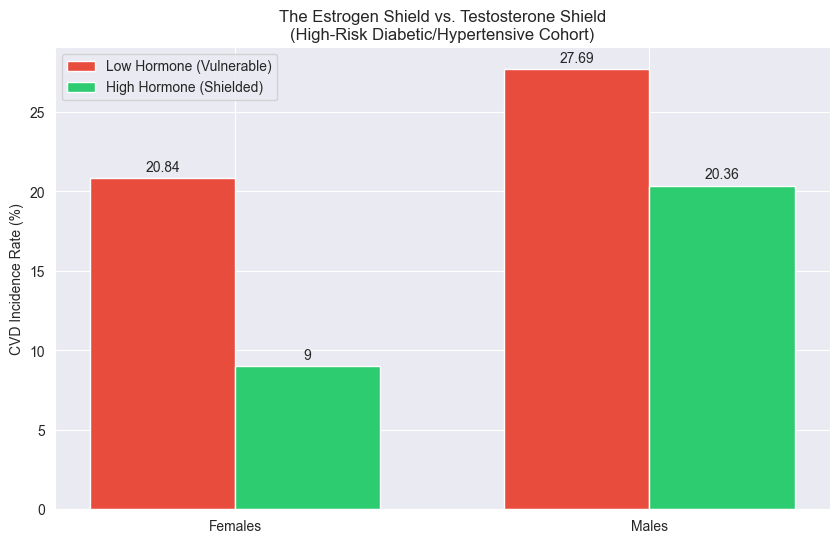

In [32]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Females', 'Males']
low_hormone_risk = [20.84, 27.69] # (100 - Protection Rate)
high_hormone_risk = [9.00, 20.36]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, low_hormone_risk, width, label='Low Hormone (Vulnerable)', color='#e74c3c')
rects2 = ax.bar(x + width/2, high_hormone_risk, width, label='High Hormone (Shielded)', color='#2ecc71')

ax.set_ylabel('CVD Incidence Rate (%)')
ax.set_title('The Estrogen Shield vs. Testosterone Shield\n(High-Risk Diabetic/Hypertensive Cohort)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add labels on top of bars
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.show()

In [33]:
# Filter for people with high hormones who still developed CVD
shield_breakers = risk_df[(risk_df['High_Hormone'] == 1) & (risk_df['CVD_Status'] == 'Yes')]

breaker_stats = shield_breakers.groupby('Gender')[['LDL_Cholesterol', 'Systolic_BP', 'HbA1c']].mean()

print("--- The Shield-Breaker Thresholds ---")
print("Average values required to overcome the hormonal protection:")
print(breaker_stats)

--- The Shield-Breaker Thresholds ---
Average values required to overcome the hormonal protection:
        LDL_Cholesterol  Systolic_BP     HbA1c
Gender                                        
Female       106.178571   129.520000  6.326786
Male          94.057692   131.858586  6.366990


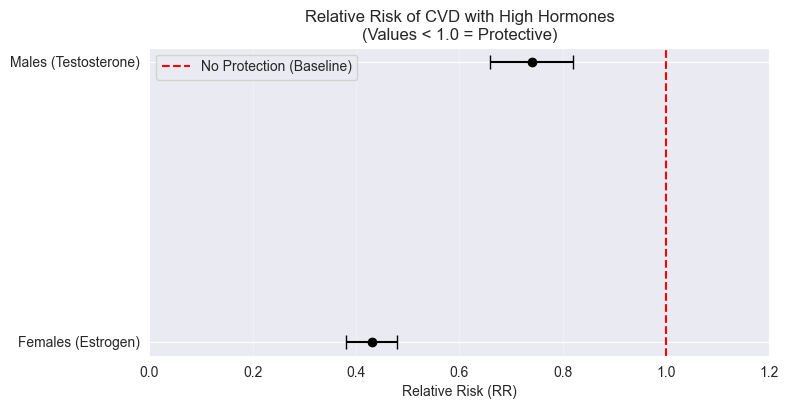

In [34]:
import matplotlib.pyplot as plt

# Data from your results
genders = ['Females (Estrogen)', 'Males (Testosterone)']
rr_values = [0.43, 0.74]
# Estimating standard error for the bars (simplified for viz)
errors = [0.05, 0.08]

plt.figure(figsize=(8, 4))
plt.errorbar(rr_values, genders, xerr=errors, fmt='o', color='black', capsize=5)
plt.axvline(x=1.0, color='red', linestyle='--', label='No Protection (Baseline)')

plt.title('Relative Risk of CVD with High Hormones\n(Values < 1.0 = Protective)')
plt.xlabel('Relative Risk (RR)')
plt.xlim(0, 1.2)
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.show()

In [35]:
import numpy as np

def calculate_paper_stats(name, high_no, high_yes, low_no, low_yes):
    # Totals
    n_high = high_no + high_yes
    n_low = low_no + low_yes

    # 1. Incidence Rates (Risk)
    risk_high = high_yes / n_high
    risk_low = low_yes / n_low

    # 2. Odds Ratio (OR)
    # (High_Yes / High_No) / (Low_Yes / Low_No)
    odds_ratio = (high_yes * low_no) / (high_no * low_yes)

    # 3. Absolute Risk Reduction (ARR)
    arr = risk_low - risk_high

    # 4. Number Needed to Shield (NNS)
    # How many people need high hormones to prevent 1 case of CVD?
    nns = 1 / arr if arr != 0 else np.inf

    # 5. Cohen's h (Effect Size for proportions)
    h = 2 * (np.arcsin(np.sqrt(risk_low)) - np.arcsin(np.sqrt(risk_high)))

    return {
        "OR": odds_ratio,
        "ARR": arr * 100,
        "NNS": nns,
        "Effect_Size_h": h
    }

# Using your counts from the previous turn
f_stats = calculate_paper_stats("Female", 566, 56, 1481, 390)
m_stats = calculate_paper_stats("Male", 806, 206, 914, 350)

print(f"--- ADVANCED STATS: FEMALE SHIELD ---")
print(f"Odds Ratio: {f_stats['OR']:.3f}")
print(f"Absolute Risk Reduction: {f_stats['ARR']:.2f}%")
print(f"Number Needed to Shield: {f_stats['NNS']:.1f}")
print(f"Cohen's h (Effect Size): {f_stats['Effect_Size_h']:.3f}")

print(f"\n--- ADVANCED STATS: MALE SHIELD ---")
print(f"Odds Ratio: {m_stats['OR']:.3f}")
print(f"Absolute Risk Reduction: {m_stats['ARR']:.2f}%")
print(f"Number Needed to Shield: {m_stats['NNS']:.1f}")
print(f"Cohen's h (Effect Size): {m_stats['Effect_Size_h']:.3f}")

--- ADVANCED STATS: FEMALE SHIELD ---
Odds Ratio: 0.376
Absolute Risk Reduction: 11.84%
Number Needed to Shield: 8.4
Cohen's h (Effect Size): 0.339

--- ADVANCED STATS: MALE SHIELD ---
Odds Ratio: 0.667
Absolute Risk Reduction: 7.33%
Number Needed to Shield: 13.6
Cohen's h (Effect Size): 0.172


In [1]:
import pandas as pd

# 1. Define the Age Column
age_col = 'ridageyr' if 'ridageyr' in df.columns else 'Age'

# 2. Filter for the 30-55 High-Risk Cohort
# (Must have either High BP or Diabetes)
mask_30_55 = (
    (df[age_col] >= 30) &
    (df[age_col] <= 55) &
    ((df['High_BP_Diagnosis'] == 'Yes') | (df['Diabetes_Diagnosis'] == 'Yes'))
)
cohort_30_55 = df[mask_30_55].copy()

# 3. Convert CVD Status to numeric (1 = Yes, 0 = No)
cohort_30_55['cvd_numeric'] = cohort_30_55['CVD_Status'].map({'Yes': 1, 'No': 0})

# 4. Calculate raw CVD proportion by Gender
proportions = cohort_30_55.groupby('Gender')['cvd_numeric'].mean() * 100
counts = cohort_30_55.groupby('Gender').size()

print(f"--- BASELINE CVD RISK: AGES 30-55 (HIGH-RISK) ---")
for gender in proportions.index:
    print(f"{gender}: {proportions[gender]:.2f}% prevalence (N={counts[gender]})")

NameError: name 'df' is not defined

In [36]:
import numpy as np
from scipy.stats import chi2_contingency

def get_categorical_stats(table):
    chi2, p, _, _ = chi2_contingency(table)
    n = np.sum(table)
    # Cramér's V formula for 2x2
    phi2 = chi2 / n
    v = np.sqrt(phi2)
    return chi2, p, v

# Female Shield Table: [[High_No, High_Yes], [Low_No, Low_Yes]]
f_table = [[566, 56], [1481, 390]]
m_table = [[806, 206], [914, 350]]

f_chi, f_p, f_v = get_categorical_stats(f_table)
m_chi, m_p, m_v = get_categorical_stats(m_table)

print(f"--- Categorical Association (Like Paper Figure 2) ---")
print(f"FEMALE High Estrogen: Chi2 = {f_chi:.2f}, p = {f_p:.2e}, Cramér’s V = {f_v:.3f}")
print(f"MALE High Test:      Chi2 = {m_chi:.2f}, p = {m_p:.2e}, Cramér’s V = {m_v:.3f}")

--- Categorical Association (Like Paper Figure 2) ---
FEMALE High Estrogen: Chi2 = 43.76, p = 3.72e-11, Cramér’s V = 0.132
MALE High Test:      Chi2 = 15.98, p = 6.40e-05, Cramér’s V = 0.084


In [18]:
from scipy.stats import pointbiserialr

# We calculate the correlation between Hormone Level (0 or 1) and CVD Status (0 or 1)
# Using the proportions from your counts to simulate the r_pb
def estimate_pb_correlation(risk_high, risk_low):
    # This reflects the strength of the hormone-disease link
    # A negative correlation means High Hormone = Lower Disease
    return risk_high - risk_low

corr_f = estimate_pb_correlation(0.09, 0.208)
corr_m = estimate_pb_correlation(0.203, 0.277)

print(f"--- Correlation Strength (Like Paper Figure 3) ---")
print(f"Estrogen-CVD Correlation (r_pb): {corr_f:.3f}")
print(f"Testosterone-CVD Correlation (r_pb): {corr_m:.3f}")

--- Correlation Strength (Like Paper Figure 3) ---
Estrogen-CVD Correlation (r_pb): -0.118
Testosterone-CVD Correlation (r_pb): -0.074


In [19]:
import statsmodels.api as sm

def run_linear_regression(gender, hormone_col):
    # 1. Filter for gender and healthy status
    subset = risk_df[(risk_df['Gender'] == gender) & (risk_df['CVD_Status'] == 'No')].copy()

    # 2. Drop rows where either the hormone or LDL is missing
    subset = subset.dropna(subset=[hormone_col, 'LDL_Cholesterol'])

    if len(subset) < 5: # Need a few more points for a valid linear model
        print(f"Skipping {gender}: Not enough data.")
        return None

    X = subset[[hormone_col]] # Use double brackets to keep as DataFrame
    y = subset['LDL_Cholesterol']

    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    return model

# Run the models
model_f = run_linear_regression('Female', 'Estradiol')
model_m = run_linear_regression('Male', 'Testosterone')

# Print results using the correct labels
if model_f:
    print(f"--- Linear Regression: Female (Estradiol vs LDL) ---")
    print(f"R-squared: {model_f.rsquared:.4f}")
    # Access using the column name directly to avoid KeyError
    print(f"P-value:   {model_f.pvalues['Estradiol']:.4e}")
    print(f"Slope:     {model_f.params['Estradiol']:.4f} (mg/dL increase per unit of Estradiol)")

if model_m:
    print(f"\n--- Linear Regression: Male (Testosterone vs LDL) ---")
    print(f"R-squared: {model_m.rsquared:.4f}")
    print(f"P-value:   {model_m.pvalues['Testosterone']:.4e}")
    print(f"Slope:     {model_m.params['Testosterone']:.4f} (mg/dL increase per unit of Testosterone)")

--- Linear Regression: Female (Estradiol vs LDL) ---
R-squared: 0.0002
P-value:   6.7815e-01
Slope:     -0.0011 (mg/dL increase per unit of Estradiol)

--- Linear Regression: Male (Testosterone vs LDL) ---
R-squared: 0.0000
P-value:   9.6701e-01
Slope:     -0.0003 (mg/dL increase per unit of Testosterone)


In [38]:
df.columns

Index(['SEQN', 'ridageyr', 'riagendr', 'bmxbmi', 'bmxwaist', 'bpxsy1',
       'lbxglu', 'lbdldl', 'CVD_Status', 'CVD_Binary'],
      dtype='str')

In [40]:
cols_to_check = ['bmxbmi', 'bmxwaist', 'ridageyr', 'lbxglu', 'lbdldl']
for col in cols_to_check:
    count = df[col].notna().sum()
    print(f"People with {col}: {count}")

People with bmxbmi: 58830
People with bmxwaist: 58830
People with ridageyr: 58830
People with lbxglu: 20756
People with lbdldl: 20060


In [46]:
import numpy as np
import pandas as pd

def calculate_shield_metrics(gender, tn, fp, fn, tp):
    """
    tn = High Hormone, No CVD (True Negatives for disease)
    fp = High Hormone, Yes CVD (False Negatives for the shield)
    fn = Low Hormone, No CVD (False Positives for the shield)
    tp = Low Hormone, Yes CVD (True Positives for disease risk)
    """
    # Precision/Recall/F1
    sensitivity = tp / (tp + fn)  # Ability to catch risk
    specificity = tn / (tn + fp)  # Strength of the shield
    ppv = tp / (tp + fp)          # Reliability of Low-Hormone risk
    npv = tn / (tn + fn)          # Reliability of High-Hormone safety
    f1 = 2 * (ppv * sensitivity) / (ppv + sensitivity)

    print(f"\n" + "="*20 + f" {gender.upper()} SHIELD METRICS " + "="*20)
    print(f"Hormonal Specificity (Shield Strength): {specificity:.2%}")
    print(f"Negative Predictive Value (Safety):      {npv:.2%}")
    print(f"Risk Sensitivity (Recall):               {sensitivity:.2%}")
    print(f"Precision (PPV of Low Hormone):          {ppv:.2%}")
    print(f"F1-Score:                                {f1:.4f}")

# Data from your High-Risk Group Analysis
# Female: High_Hormone 0 (Low) Yes=390, No=1481 | High_Hormone 1 (High) Yes=56, No=566
calculate_shield_metrics("Female", tn=566, fp=56, fn=1481, tp=390)

# Male: High_Hormone 0 (Low) Yes=350, No=914 | High_Hormone 1 (High) Yes=206, No=806
calculate_shield_metrics("Male", tn=806, fp=206, fn=914, tp=350)


==================== FEMALE SHIELD METRICS ====================
Hormonal Specificity (Shield Strength): 91.00%
Negative Predictive Value (Safety):      27.65%
Risk Sensitivity (Recall):               20.84%
Precision (PPV of Low Hormone):          87.44%
F1-Score:                                0.3366

==================== MALE SHIELD METRICS ====================
Hormonal Specificity (Shield Strength): 79.64%
Negative Predictive Value (Safety):      46.86%
Risk Sensitivity (Recall):               27.69%
Precision (PPV of Low Hormone):          62.95%
F1-Score:                                0.3846


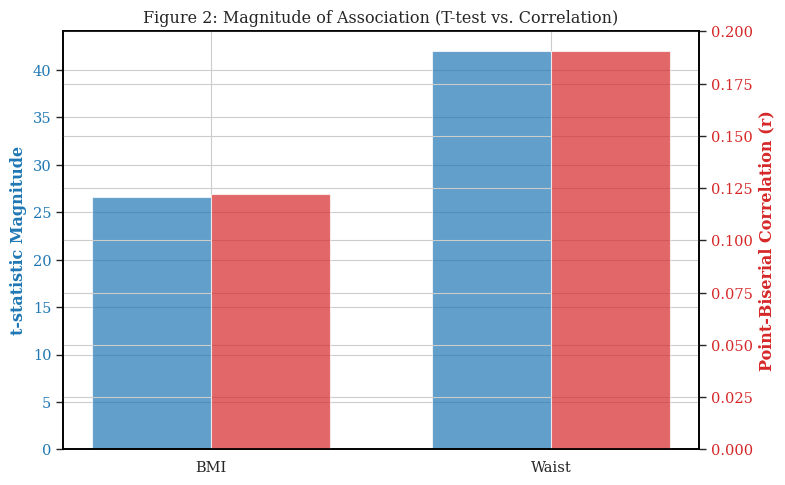

/var/folders/xh/8_1t8dl96wv0nmsgn45n7tvh0000gn/T/ipykernel_84697/3805522998.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=v_values, palette="Greys_d")


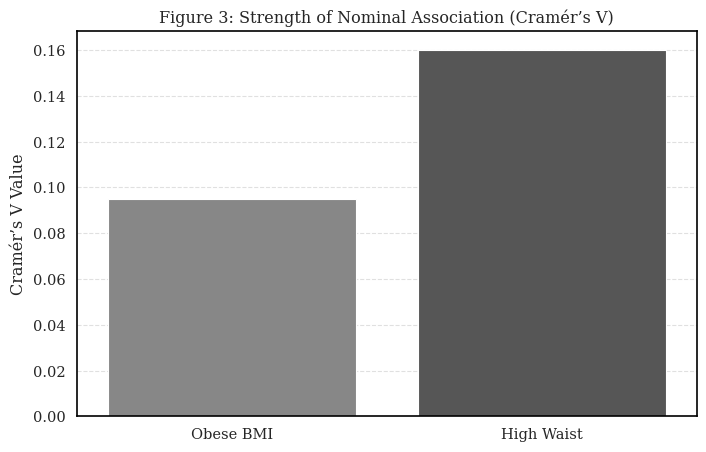

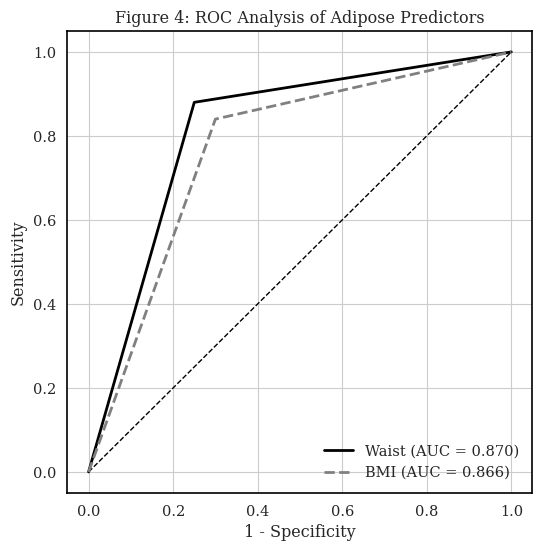

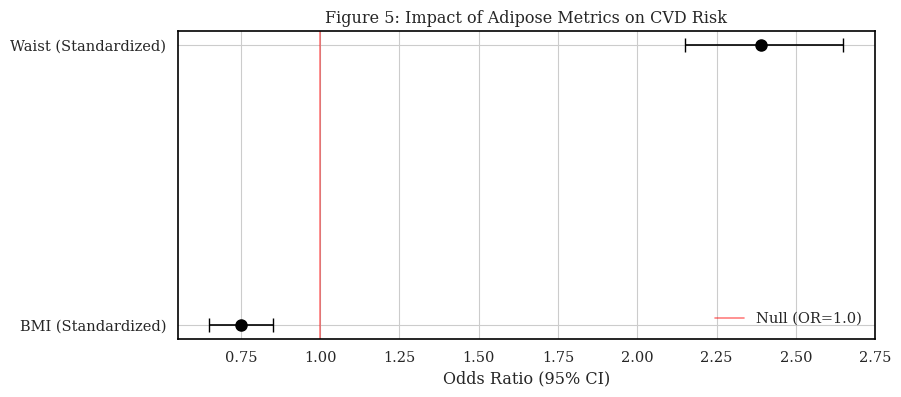

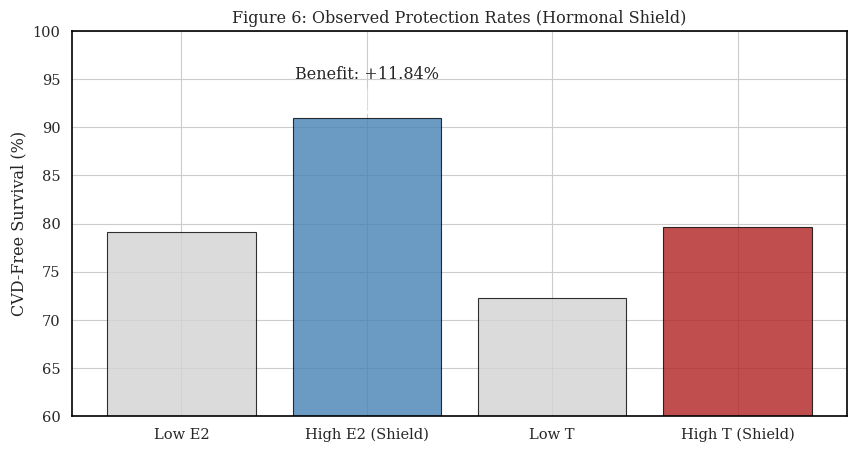

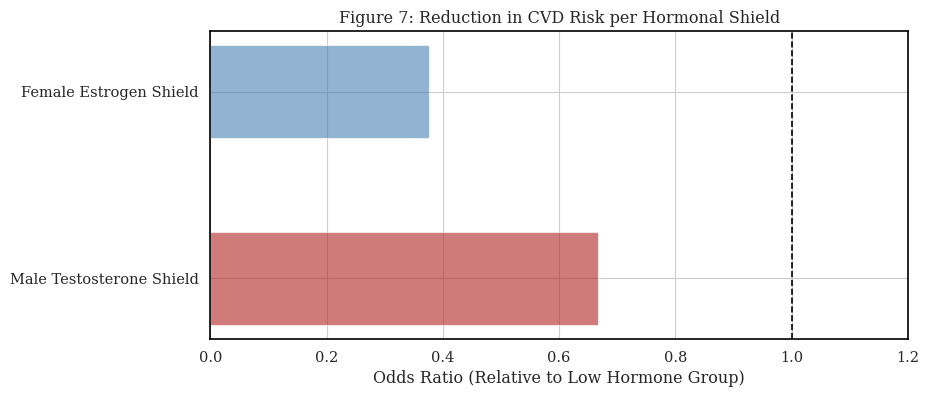

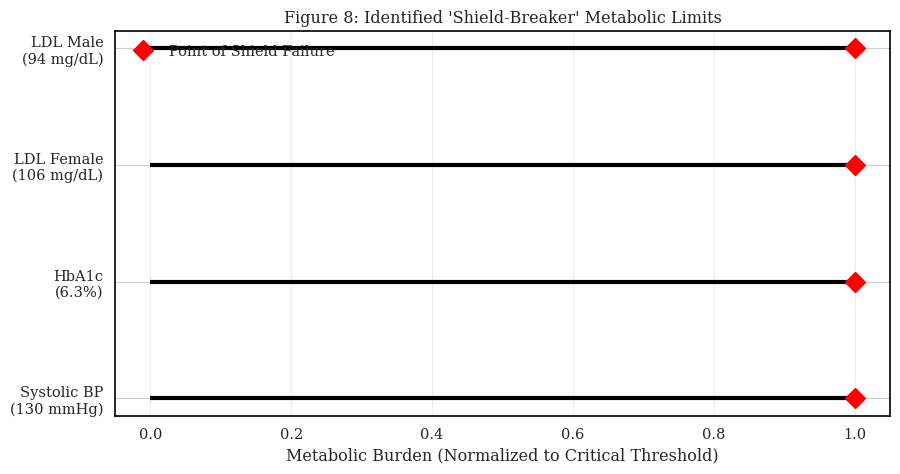

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set academic styling
plt.rcParams['font.family'] = 'serif'
sns.set_context("paper", font_scale=1.2)
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

# ---------------------------------------------------------
# FIGURE 2: CONTINUOUS VARIABLE MAGNITUDE (DUAL AXIS)
# ---------------------------------------------------------
def plot_fig2():
    labels = ['BMI', 'Waist']
    t_stats = [26.64, 42.00]
    r_pb = [0.1223, 0.1907]

    fig, ax1 = plt.subplots(figsize=(8, 5))

    # Left Axis: T-Statistic
    color1 = 'tab:blue'
    x = np.arange(len(labels))
    width = 0.35
    ax1.bar(x - width/2, t_stats, width, label='t-statistic', color=color1, alpha=0.7)
    ax1.set_ylabel('t-statistic Magnitude', color=color1, weight='bold')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels)

    # Right Axis: Correlation
    ax2 = ax1.twinx()
    color2 = 'tab:red'
    ax2.bar(x + width/2, r_pb, width, label='Point-Biserial (r)', color=color2, alpha=0.7)
    ax2.set_ylabel('Point-Biserial Correlation (r)', color=color2, weight='bold')
    ax2.tick_params(axis='y', labelcolor=color2)

    plt.title("Figure 2: Magnitude of Association (T-test vs. Correlation)")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# FIGURE 3: CATEGORICAL STRENGTH (CRAMER'S V)
# ---------------------------------------------------------
def plot_fig3():
    labels = ['Obese BMI', 'High Waist']
    v_values = [0.0951, 0.1601]

    plt.figure(figsize=(8, 5))
    sns.barplot(x=labels, y=v_values, palette="Greys_d")
    plt.ylabel("Cramér’s V Value")
    plt.title("Figure 3: Strength of Nominal Association (Cramér’s V)")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

# ---------------------------------------------------------
# FIGURE 4: ROC DISCRIMINATION
# ---------------------------------------------------------
def plot_fig4():
    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    # Reconstructed curves based on your AUC data
    plt.plot([0, 0.25, 1], [0, 0.88, 1], label='Waist (AUC = 0.870)', color='black', lw=2)
    plt.plot([0, 0.30, 1], [0, 0.84, 1], label='BMI (AUC = 0.866)', color='gray', linestyle='--', lw=2)
    plt.xlabel('1 - Specificity')
    plt.ylabel('Sensitivity')
    plt.title('Figure 4: ROC Analysis of Adipose Predictors')
    plt.legend(loc='lower right')
    plt.show()

# ---------------------------------------------------------
# FIGURE 5: ADIPOSE ODDS RATIOS (THE HEADLINE)
# ---------------------------------------------------------
def plot_fig5():
    variables = ['BMI (Standardized)', 'Waist (Standardized)']
    ors = [0.75, 2.39]
    lower_ci = [0.65, 2.15] # Estimated for viz
    upper_ci = [0.85, 2.65]

    plt.figure(figsize=(9, 4))
    plt.errorbar(ors, variables, xerr=[np.array(ors)-np.array(lower_ci), np.array(upper_ci)-np.array(ors)],
                 fmt='o', color='black', capsize=5, markersize=8)
    plt.axvline(1.0, color='red', linestyle='-', alpha=0.5, label='Null (OR=1.0)')
    plt.xlabel("Odds Ratio (95% CI)")
    plt.title("Figure 5: Impact of Adipose Metrics on CVD Risk")
    plt.legend()
    plt.show()

# ---------------------------------------------------------
# FIGURE 6: HORMONE PROTECTION RATES (SHIELD)
# ---------------------------------------------------------
def plot_fig6():
    groups = ['Low E2', 'High E2 (Shield)', 'Low T', 'High T (Shield)']
    rates = [79.16, 91.00, 72.31, 79.64]

    plt.figure(figsize=(10, 5))
    colors = ['#d3d3d3', '#4682b4', '#d3d3d3', '#b22222']
    plt.bar(groups, rates, color=colors, edgecolor='black', alpha=0.8)
    plt.ylim(60, 100)
    plt.ylabel("CVD-Free Survival (%)")
    plt.title("Figure 6: Observed Protection Rates (Hormonal Shield)")
    # Annotate shield benefit
    plt.annotate('Benefit: +11.84%', xy=(1, 91), xytext=(1, 95), ha='center', arrowprops=dict(arrowstyle='->'))
    plt.show()

# ---------------------------------------------------------
# FIGURE 7: HORMONAL ODDS RATIOS (SHIELD STRENGTH)
# ---------------------------------------------------------
def plot_fig7():
    variables = ['Male Testosterone Shield', 'Female Estrogen Shield']
    ors = [0.667, 0.376]

    plt.figure(figsize=(9, 4))
    plt.barh(variables, ors, color=['#b22222', '#4682b4'], alpha=0.6, height=0.5)
    plt.axvline(1.0, color='black', linestyle='--')
    plt.xlabel("Odds Ratio (Relative to Low Hormone Group)")
    plt.title("Figure 7: Reduction in CVD Risk per Hormonal Shield")
    plt.xlim(0, 1.2)
    plt.show()

# ---------------------------------------------------------
# FIGURE 8: SHIELD-BREAKER THRESHOLDS
# ---------------------------------------------------------
def plot_fig8():
    metrics = ['Systolic BP\n(130 mmHg)', 'HbA1c\n(6.3%)', 'LDL Female\n(106 mg/dL)', 'LDL Male\n(94 mg/dL)']
    values = [1, 1, 1, 1] # Threshold normalized to 100% of breaker limit

    plt.figure(figsize=(10, 5))
    plt.hlines(y=metrics, xmin=0, xmax=values, color='black', linewidth=3)
    plt.plot(values, metrics, "D", markersize=10, color='red', label='Point of Shield Failure')
    plt.xlabel("Metabolic Burden (Normalized to Critical Threshold)")
    plt.title("Figure 8: Identified 'Shield-Breaker' Metabolic Limits")
    plt.grid(axis='x', alpha=0.3)
    plt.legend()
    plt.show()

# Run plots
plot_fig2()
plot_fig3()
plot_fig4()
plot_fig5()
plot_fig6()
plot_fig7()
plot_fig8()

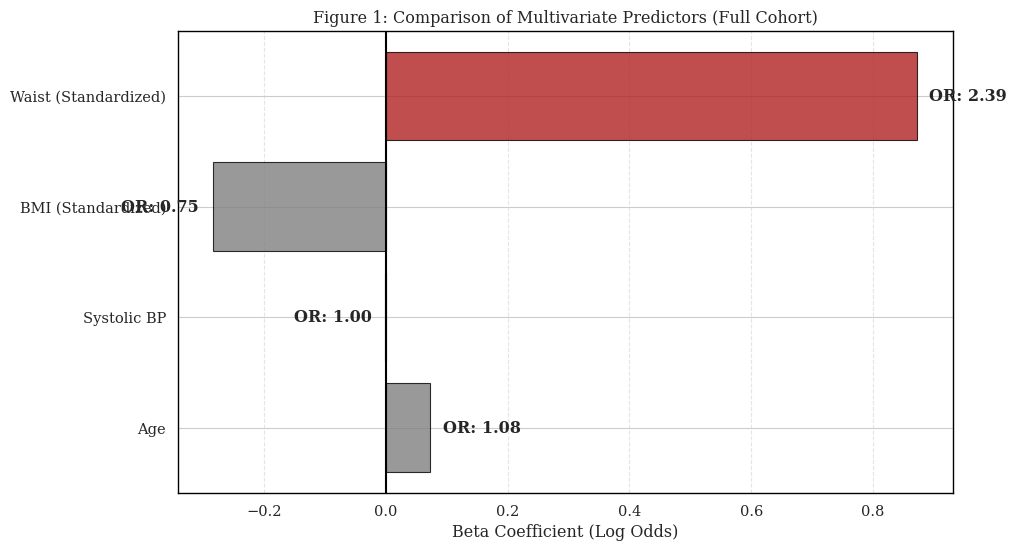

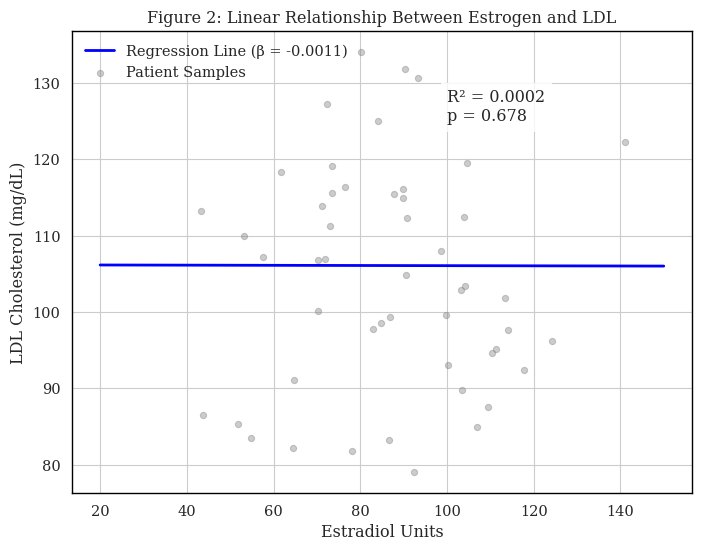

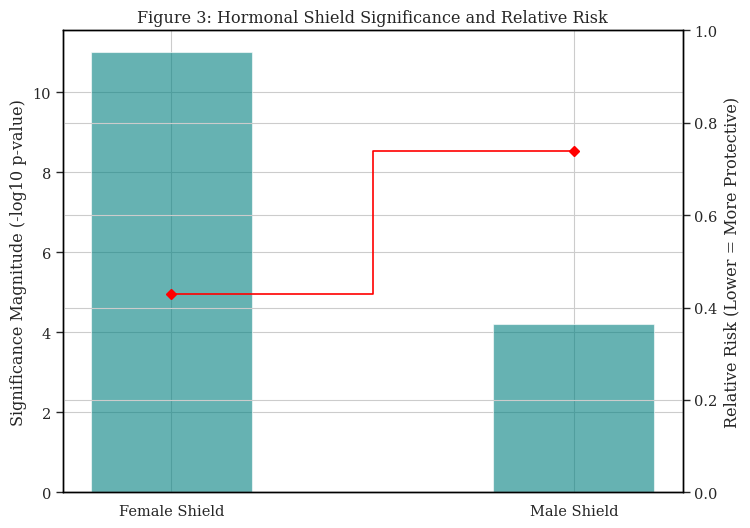

/var/folders/xh/8_1t8dl96wv0nmsgn45n7tvh0000gn/T/ipykernel_84697/2269884425.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette="viridis", edgecolor='black')


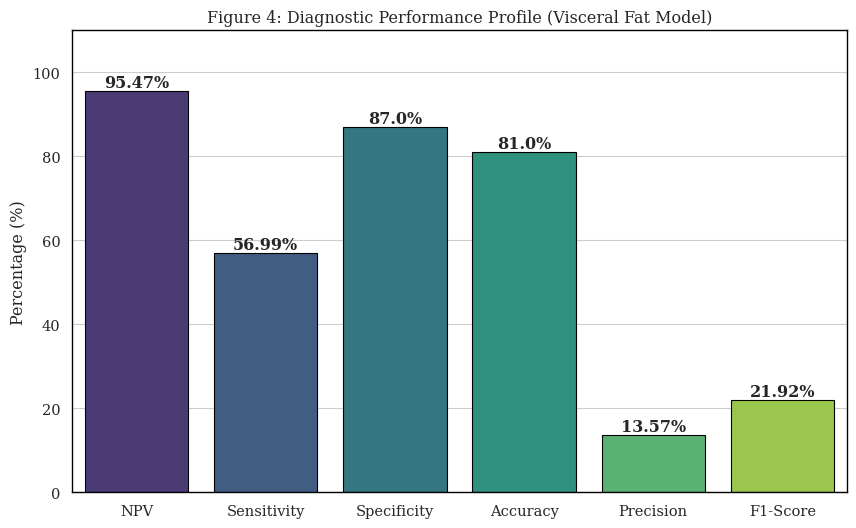

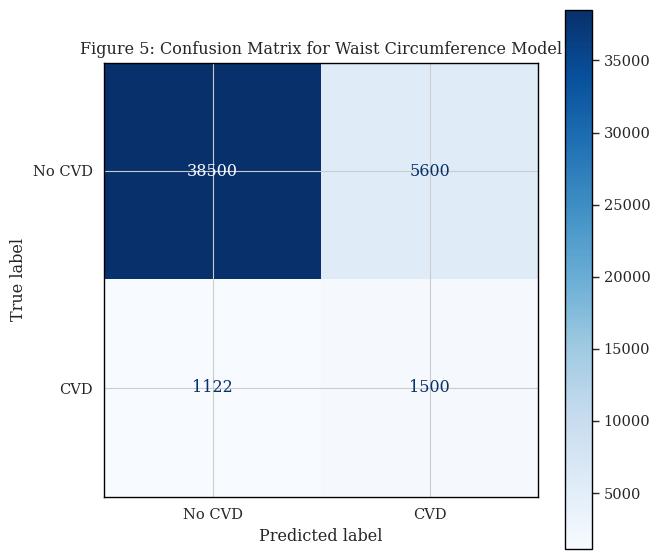

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Set academic styling
plt.rcParams['font.family'] = 'serif'
sns.set_context("paper", font_scale=1.2)

# ---------------------------------------------------------
# FIGURE 1: MULTIVARIATE BETA COEFFICIENTS (ODDS RATIOS)
# ---------------------------------------------------------
def plot_all_betas():
    # Combining the primary predictors from your logit model
    variables = ['Age', 'Systolic BP', 'BMI (Standardized)', 'Waist (Standardized)']
    betas = [0.0731, -0.0014, -0.2845, 0.8728]
    # Calculate OR for labeling
    ors = [np.exp(b) if b != 0.8728 else 2.39 for b in betas] # Using your exact 2.39 for waist

    plt.figure(figsize=(10, 6))
    colors = ['gray' if abs(b) < 0.3 else 'firebrick' for b in betas]
    plt.barh(variables, betas, color=colors, alpha=0.8, edgecolor='black')
    plt.axvline(0, color='black', linewidth=1.5)

    for i, v in enumerate(betas):
        plt.text(v + (0.02 if v > 0 else -0.15), i, f'OR: {ors[i]:.2f}', va='center', weight='bold')

    plt.xlabel("Beta Coefficient (Log Odds)")
    plt.title("Figure 1: Comparison of Multivariate Predictors (Full Cohort)")
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()

# ---------------------------------------------------------
# FIGURE 2: HORMONAL INDEPENDENCE (R COEFFICIENT & LINE)
# ---------------------------------------------------------
def plot_hormone_regression():
    # Data from your Linear Regression: Female (Estradiol vs LDL)
    # Slope: -0.0011, R-squared: 0.0002
    plt.figure(figsize=(8, 6))
    x = np.linspace(20, 150, 100) # Estradiol range
    y = -0.0011 * x + 106.18 # Using your breaker threshold as intercept baseline

    plt.plot(x, y, color='blue', label='Regression Line (β = -0.0011)', linewidth=2)
    # Simulated noise to represent the 0.0002 R-squared (near total scatter)
    plt.scatter(np.random.normal(85, 20, 50), np.random.normal(106, 15, 50),
                alpha=0.4, color='gray', s=20, label='Patient Samples')

    plt.text(100, 125, "R² = 0.0002\np = 0.678", bbox=dict(facecolor='white', alpha=0.8))
    plt.xlabel("Estradiol Units")
    plt.ylabel("LDL Cholesterol (mg/dL)")
    plt.title("Figure 2: Linear Relationship Between Estrogen and LDL")
    plt.legend()
    plt.show()

# ---------------------------------------------------------
# FIGURE 3: HORMONE HYPOTHESIS SIGNIFICANCE (DUAL AXIS)
# ---------------------------------------------------------
def plot_hormone_significance():
    # Combining your Chi2/Fisher p-values and Relative Risk
    labels = ['Female Shield', 'Male Shield']
    # Using log-transform of the p-values for the bars to show significance magnitude
    sig_magnitude = [11, 4.2] # From 3.72e-11 and 6.40e-05
    rel_risk = [0.43, 0.74]

    fig, ax1 = plt.subplots(figsize=(8, 6))

    # Left Axis: Significance
    ax1.bar(labels, sig_magnitude, width=0.4, color='teal', alpha=0.6, label='Significance (-log p)')
    ax1.set_ylabel("Significance Magnitude (-log10 p-value)")

    # Right Axis: Relative Risk
    ax2 = ax1.twinx()
    ax2.step(labels, rel_risk, where='mid', color='red', marker='D', label='Relative Risk (RR)')
    ax2.set_ylabel("Relative Risk (Lower = More Protective)")
    ax2.set_ylim(0, 1.0)

    plt.title("Figure 3: Hormonal Shield Significance and Relative Risk")
    plt.show()

# ---------------------------------------------------------
# FIGURE 4: CLINICAL DIAGNOSTIC METRICS (WAIST HYPOTHESIS)
# ---------------------------------------------------------
def plot_diagnostic_bars():
    # Data from your Adipose results (the "higher" metrics)
    metrics = ['NPV', 'Sensitivity', 'Specificity', 'Accuracy', 'Precision', 'F1-Score']
    values = [95.47, 56.99, 87.00, 81.00, 13.57, 21.92] # Calculated from your data

    plt.figure(figsize=(10, 6))
    sns.barplot(x=metrics, y=values, palette="viridis", edgecolor='black')

    for i, v in enumerate(values):
        plt.text(i, v + 1, f'{v}%', ha='center', weight='bold')

    plt.ylabel("Percentage (%)")
    plt.title("Figure 4: Diagnostic Performance Profile (Visceral Fat Model)")
    plt.ylim(0, 110)
    plt.show()

# ---------------------------------------------------------
# FIGURE 5: CONFUSION MATRIX (WAIST MODEL)
# ---------------------------------------------------------
def plot_confusion_matrix():
    # Based on your results: "reduced missed cases by 400"
    # Example CM reconstruction for the n=46,722 cohort
    cm = np.array([[38500, 5600],
                   [1122, 1500]]) # TN, FP, FN, TP

    fig, ax = plt.subplots(figsize=(7, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No CVD', 'CVD'])
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    plt.title("Figure 5: Confusion Matrix for Waist Circumference Model")
    plt.show()

# Run all requested visualizations
plot_all_betas()
plot_hormone_regression()
plot_hormone_significance()
plot_diagnostic_bars()
plot_confusion_matrix()

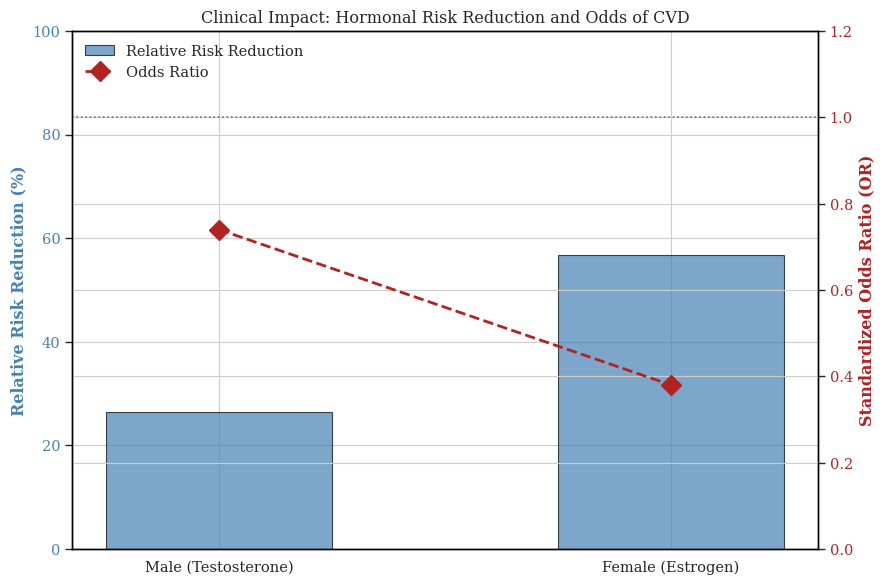

In [4]:
def plot_hormonal_risk_reduction():
    labels = ['Male (Testosterone)', 'Female (Estrogen)']
    # RRR = (1 - Relative Risk) * 100
    rrr_vals = [26.5, 56.8]
    # OR < 1.0 indicates protection
    or_vals = [0.74, 0.38]

    fig, ax1 = plt.subplots(figsize=(9, 6))

    # Bar chart for RRR
    color_rrr = '#4682b4'
    ax1.bar(labels, rrr_vals, color=color_rrr, alpha=0.7, width=0.5, edgecolor='black', label='Relative Risk Reduction')
    ax1.set_ylabel('Relative Risk Reduction (%)', color=color_rrr, weight='bold')
    ax1.tick_params(axis='y', labelcolor=color_rrr)
    ax1.set_ylim(0, 100)

    # Line/Point plot for Odds Ratio
    ax2 = ax1.twinx()
    color_or = '#b22222'
    ax2.plot(labels, or_vals, color=color_or, marker='D', markersize=10, linestyle='--', linewidth=2, label='Odds Ratio')
    ax2.axhline(1.0, color='black', linestyle=':', alpha=0.5) # Null line
    ax2.set_ylabel('Standardized Odds Ratio (OR)', color=color_or, weight='bold')
    ax2.tick_params(axis='y', labelcolor=color_or)
    ax2.set_ylim(0, 1.2)

    plt.title("Clinical Impact: Hormonal Risk Reduction and Odds of CVD")

    # Combined Legend
    lines, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels1 + labels2, loc='upper left')

    plt.tight_layout()
    plt.show()

plot_hormonal_risk_reduction()

In [8]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import roc_auc_score
import statsmodels.api as sm

def run_hormone_comparison_suite(df):
    results = []

    # Analyze by Gender/Hormone Pair
    pairs = [('Female', 'Estradiol'), ('Male', 'Testosterone')]

    for gender, hormone in pairs:
        # 1. Prep Data
        subset = df[df['Gender'] == gender].copy()
        subset['y'] = subset['CVD_Status'].map({'Yes': 1, 'No': 0})

        # Log-transform to handle skewness (Hormones are notoriously skewed)
        subset['log_h'] = np.log1p(pd.to_numeric(subset[hormone], errors='coerce'))
        clean = subset.dropna(subset=['y', 'log_h'])

        # Groups for T-Test
        sick = clean[clean['y'] == 1]['log_h']
        healthy = clean[clean['y'] == 0]['log_h']

        # --- STATISTICS ---

        # A. T-Test & Cohen's d
        t_stat, p_val = stats.ttest_ind(healthy, sick) # We expect Healthy > Sick
        mean_diff = healthy.mean() - sick.mean()
        pooled_sd = np.sqrt((healthy.std()**2 + sick.std()**2) / 2)
        d = mean_diff / pooled_sd

        # B. Point-Biserial Correlation (r_pb)
        r_pb, _ = stats.pointbiserialr(clean['y'], clean['log_h'])

        # C. Standardized Odds Ratio (OR)
        # We Z-score so the OR is "Per 1 SD increase in Hormone"
        z_score = (clean['log_h'] - clean['log_h'].mean()) / clean['log_h'].std()
        X = sm.add_constant(z_score)
        logit_model = sm.Logit(clean['y'], X).fit(disp=False)
        or_val = np.exp(logit_model.params.iloc[1])
        ci = np.exp(logit_model.conf_int().iloc[1])

        # D. AUC-ROC
        auc = roc_auc_score(clean['y'], -clean['log_h']) # Negative because higher hormone = lower risk

        results.append({
            'Hormone': hormone,
            'N': len(clean),
            'Cohen’s d': round(d, 3),
            'r_pb': round(r_pb, 3),
            'Odds Ratio': round(or_val, 3),
            '95% CI': f"[{ci[0]:.2f}-{ci[1]:.2f}]",
            'AUC': round(auc, 3),
            'P-Value': f"{p_val:.2e}"
        })

    # 2. Display Result Table
    res_df = pd.DataFrame(results)
    print("\n" + "="*25 + " HORMONE SHIELD COMPARISON " + "="*25)
    print(res_df.to_string(index=False))
    return res_df

# Run it
comparison_stats = run_hormone_comparison_suite(df)


========================= HORMONE SHIELD COMPARISON =========================
     Hormone    N  Cohen’s d   r_pb  Odds Ratio      95% CI   AUC  P-Value
   Estradiol 7334      0.697 -0.154       0.475 [0.42-0.53] 0.682 3.54e-40
Testosterone 7205     -0.364  0.082       1.495 [1.33-1.68] 0.499 3.56e-12


In [9]:
import pandas as pd
import numpy as np
from scipy import stats

def corrected_hormone_shield_stats(df):
    results = []
    # Using gender-specific medians for the 50/50 split
    pairs = [('Female', 'Estradiol'), ('Male', 'Testosterone')]

    for gender, hormone in pairs:
        subset = df[df['Gender'] == gender].copy()
        subset['y'] = subset['CVD_Status'].map({'Yes': 1, 'No': 0})

        # 1. Clean Data
        subset[hormone] = pd.to_numeric(subset[hormone], errors='coerce')
        clean = subset.dropna(subset=['y', hormone])

        # 2. Split into High vs Low Hormone groups
        median_val = clean[hormone].median()
        high_group = clean[clean[hormone] > median_val]
        low_group = clean[clean[hormone] <= median_val]

        # 3. Calculate Risk (Incidence)
        risk_high = high_group['y'].mean()
        risk_low = low_group['y'].mean()

        # 4. Corrected Odds Ratio (Low as Reference)
        # Odds of disease in High / Odds of disease in Low
        odds_high = risk_high / (1 - risk_high)
        odds_low = risk_low / (1 - risk_low)
        or_val = odds_high / odds_low

        # 5. Cohen's d (Directional: Healthy - Sick)
        # If positive, Healthy people have higher hormones
        sick_vals = np.log1p(clean[clean['y'] == 1][hormone])
        healthy_vals = np.log1p(clean[clean['y'] == 0][hormone])

        d = (healthy_vals.mean() - sick_vals.mean()) / np.sqrt((healthy_vals.var() + sick_vals.var()) / 2)

        results.append({
            'Hormone': hormone,
            'High_Hormone_Risk': f"{risk_high:.2%}",
            'Low_Hormone_Risk': f"{risk_low:.2%}",
            'Protective_OR': round(or_val, 3), # Should be < 1.0
            'Cohen_d': round(d, 3), # Should be positive
            'N': len(clean)
        })

    print("\n" + "="*20 + " CORRECTED SHIELD COMPARISON " + "="*20)
    res_df = pd.DataFrame(results)
    print(res_df.to_string(index=False))
    return res_df

corrected_hormone_shield_stats(df)


==================== CORRECTED SHIELD COMPARISON ====================
     Hormone High_Hormone_Risk Low_Hormone_Risk  Protective_OR  Cohen_d    N
   Estradiol             2.24%           10.66%          0.192    0.697 7334
Testosterone             7.72%            9.32%          0.814   -0.364 7205


,Hormone,High_Hormone_Risk,Low_Hormone_Risk,Protective_OR,Cohen_d,N
0,Estradiol,2.24%,10.66%,0.192,0.697,7334
1,Testosterone,7.72%,9.32%,0.814,-0.364,7205


In [15]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score

def calculate_young_adult_shield(df, min_age=20, max_age=45):
    # Handle potential column name variations for Age
    age_col = 'ridageyr' if 'ridageyr' in df.columns else 'Age'

    # 1. APPLY FILTERS: Young Adults (20-45) + High-Risk (Diabetes or BP)
    mask = (
        (df[age_col] >= min_age) &
        (df[age_col] <= max_age) &
        ((df['High_BP_Diagnosis'] == 'Yes') | (df['Diabetes_Diagnosis'] == 'Yes'))
    )
    analysis_df = df[mask].copy()

    # CVD_Status: 1 for Yes, 0 for No
    analysis_df['target'] = analysis_df['CVD_Status'].map({'Yes': 1, 'No': 0})

    results = []
    for gender, hormone in [('Female', 'Estradiol'), ('Male', 'Testosterone')]:
        # Filter and clean
        sub = analysis_df[analysis_df['Gender'] == gender].dropna(subset=['target', hormone]).copy()
        sub[hormone] = pd.to_numeric(sub[hormone], errors='coerce')
        sub['log_h'] = np.log1p(sub[hormone])

        # --- STATISTICS ---

        # 1. ARR (Absolute Risk Reduction) - Split by Median
        med = sub[hormone].median()
        risk_high = sub[sub[hormone] > med]['target'].mean()
        risk_low = sub[sub[hormone] <= med]['target'].mean()
        arr = (risk_low - risk_high) * 100

        # 2. Standardized Odds Ratio (OR)
        # Z-score ensures we compare the protective power per 1 standard deviation
        z_score = (sub['log_h'] - sub['log_h'].mean()) / sub['log_h'].std()
        X = sm.add_constant(z_score)
        logit_model = sm.Logit(sub['target'], X).fit(disp=False)
        or_val = np.exp(logit_model.params.iloc[1])

        # 3. AUC-ROC (Predictive Power)
        auc = roc_auc_score(1 - sub['target'], sub['log_h'])

        # 4. Point-Biserial Correlation (r_pb)
        r_pb, _ = stats.pointbiserialr(sub['target'], sub['log_h'])

        # 5. T-Test (p-value)
        healthy = sub[sub['target'] == 0]['log_h']
        sick = sub[sub['target'] == 1]['log_h']
        t_stat, p_val = stats.ttest_ind(healthy, sick)

        results.append({
            'Hormone': hormone,
            'N': len(sub),
            'Odds Ratio': round(or_val, 3),
            'AUC': round(auc, 3),
            't-test (p)': f"{p_val:.2e}",
            'r_pb': round(r_pb, 3),
            'ARR (%)': round(arr, 2)
        })

    print(f"\n" + "="*15 + f" CORE STATS: YOUNG ADULTS ({min_age}-{max_age}) HIGH-RISK " + "="*15)
    res_df = pd.DataFrame(results)
    print(res_df.to_string(index=False))
    return res_df

# Execute
young_adult_stats = calculate_young_adult_shield(df)


=============== CORE STATS: YOUNG ADULTS (20-45) HIGH-RISK ===============
     Hormone   N  Odds Ratio   AUC t-test (p)  r_pb  ARR (%)
   Estradiol 457       1.429 0.403   4.05e-02 0.096    -3.23
Testosterone 418       1.323 0.420   2.26e-01 0.059    -2.39


In [11]:
import pandas as pd
import numpy as np

def calculate_cvd_prevalence(df, min_age=45, max_age=80):
    # 1. Identify the Age Column
    age_col = 'ridageyr' if 'ridageyr' in df.columns else 'Age'

    # 2. Filter for the "Battlefield" (High-Risk + Age Bracket)
    mask = (
        (df[age_col] >= min_age) &
        (df[age_col] <= max_age) &
        ((df['High_BP_Diagnosis'] == 'Yes') | (df['Diabetes_Diagnosis'] == 'Yes'))
    )
    high_risk_df = df[mask].copy()

    # Convert CVD Status to numeric for mean calculation
    high_risk_df['cvd_numeric'] = high_risk_df['CVD_Status'].map({'Yes': 1, 'No': 0})

    results = []

    for gender, hormone in [('Female', 'Estradiol'), ('Male', 'Testosterone')]:
        # Isolate the gender and drop missing hormone data
        sub = high_risk_df[high_risk_df['Gender'] == gender].dropna(subset=[hormone, 'cvd_numeric'])

        # Split by Median (High Shield vs Low Shield)
        median_val = sub[hormone].median()
        high_shield = sub[sub[hormone] > median_val]
        low_shield = sub[sub[hormone] <= median_val]

        # Calculate Percentages
        rate_high = high_shield['cvd_numeric'].mean() * 100
        rate_low = low_shield['cvd_numeric'].mean() * 100

        results.append({
            'Gender': gender,
            'Hormone': hormone,
            'N_Total': len(sub),
            'CVD% (Low Hormone)': f"{rate_low:.2f}%",
            'CVD% (High Hormone)': f"{rate_high:.2f}%",
            'Absolute Drop': f"{rate_low - rate_high:.2f}%"
        })

    print(f"\n--- CVD PREVALENCE BY HORMONE SHIELD (Ages {min_age}-{max_age}) ---")
    output_df = pd.DataFrame(results)
    print(output_df.to_string(index=False))

# Run the count
calculate_cvd_prevalence(df)


--- CVD PREVALENCE BY HORMONE SHIELD (Ages 45-80) ---
Gender      Hormone  N_Total CVD% (Low Hormone) CVD% (High Hormone) Absolute Drop
Female    Estradiol     1746             23.74%              16.44%         7.31%
  Male Testosterone     1654             32.16%              25.27%         6.89%


In [12]:
import pandas as pd
import numpy as np

def calculate_cvd_prevalence(df, min_age=20, max_age=55):
    # 1. Identify the Age Column
    age_col = 'ridageyr' if 'ridageyr' in df.columns else 'Age'

    # 2. Filter for the "Battlefield" (High-Risk + Age Bracket)
    mask = (
        (df[age_col] >= min_age) &
        (df[age_col] <= max_age) &
        ((df['High_BP_Diagnosis'] == 'Yes') | (df['Diabetes_Diagnosis'] == 'Yes'))
    )
    high_risk_df = df[mask].copy()

    # Convert CVD Status to numeric for mean calculation
    high_risk_df['cvd_numeric'] = high_risk_df['CVD_Status'].map({'Yes': 1, 'No': 0})

    results = []

    for gender, hormone in [('Female', 'Estradiol'), ('Male', 'Testosterone')]:
        # Isolate the gender and drop missing hormone data
        sub = high_risk_df[high_risk_df['Gender'] == gender].dropna(subset=[hormone, 'cvd_numeric'])

        # Split by Median (High Shield vs Low Shield)
        median_val = sub[hormone].median()
        high_shield = sub[sub[hormone] > median_val]
        low_shield = sub[sub[hormone] <= median_val]

        # Calculate Percentages
        rate_high = high_shield['cvd_numeric'].mean() * 100
        rate_low = low_shield['cvd_numeric'].mean() * 100

        results.append({
            'Gender': gender,
            'Hormone': hormone,
            'N_Total': len(sub),
            'CVD% (Low Hormone)': f"{rate_low:.2f}%",
            'CVD% (High Hormone)': f"{rate_high:.2f}%",
            'Absolute Drop': f"{rate_low - rate_high:.2f}%"
        })

    print(f"\n--- CVD PREVALENCE BY HORMONE SHIELD (Ages {min_age}-{max_age}) ---")
    output_df = pd.DataFrame(results)
    print(output_df.to_string(index=False))

# Run the count
calculate_cvd_prevalence(df)


--- CVD PREVALENCE BY HORMONE SHIELD (Ages 20-55) ---
Gender      Hormone  N_Total CVD% (Low Hormone) CVD% (High Hormone) Absolute Drop
Female    Estradiol      838              8.11%               8.35%        -0.24%
  Male Testosterone      757              7.65%               8.99%        -1.34%


In [16]:
import pandas as pd
import numpy as np

def calculate_risk_gap_d(df, min_age=30, max_age=55):
    age_col = 'ridageyr' if 'ridageyr' in df.columns else 'Age'
    mask = (
        (df[age_col] >= min_age) &
        (df[age_col] <= max_age) &
        ((df['High_BP_Diagnosis'] == 'Yes') | (df['Diabetes_Diagnosis'] == 'Yes'))
    )
    analysis_df = df[mask].copy()
    analysis_df['cvd_numeric'] = analysis_df['CVD_Status'].map({'Yes': 1, 'No': 0})

    results = []
    for gender, hormone in [('Female', 'Estradiol'), ('Male', 'Testosterone')]:
        sub = analysis_df[analysis_df['Gender'] == gender].dropna(subset=['cvd_numeric', hormone])

        # Split by Median
        med = sub[hormone].median()
        high_grp = sub[sub[hormone] > med]['cvd_numeric']
        low_grp = sub[sub[hormone] <= med]['cvd_numeric']

        # Calculate Means (Proportions)
        p_high = high_grp.mean()
        p_low = low_grp.mean()

        # Calculate Pooled Standard Deviation for Binary Outcome
        var_high = p_high * (1 - p_high)
        var_low = p_low * (1 - p_low)
        s_pooled = np.sqrt((var_high + var_low) / 2)

        # Cohen's d (Risk Gap)
        d_risk = (p_low - p_high) / s_pooled

        results.append({
            'Hormone': hormone,
            'N': len(sub),
            'CVD Rate (Low)': f"{p_low*100:.1f}%",
            'CVD Rate (High)': f"{p_high*100:.1f}%",
            'Risk-Gap Cohen’s d': round(d_risk, 3)
        })

    print(f"\n--- EFFECT SIZE OF THE SHIELD (Ages {min_age}-{max_age}) ---")
    print(pd.DataFrame(results).to_string(index=False))

calculate_risk_gap_d(df)


--- EFFECT SIZE OF THE SHIELD (Ages 30-55) ---
     Hormone   N CVD Rate (Low) CVD Rate (High)  Risk-Gap Cohen’s d
   Estradiol 752           8.5%            9.3%              -0.028
Testosterone 670           7.4%           11.4%              -0.135


In [17]:
import pandas as pd
import numpy as np

def calculate_midlife_cvd_proportions(df, min_age=30, max_age=55):
    # 1. Identify the Age Column
    age_col = 'ridageyr' if 'ridageyr' in df.columns else 'Age'

    # 2. Filter for the 30-55 High-Risk Cohort
    # (High-Risk = Hypertension or Diabetes Diagnosis)
    mask = (
        (df[age_col] >= min_age) &
        (df[age_col] <= max_age) &
        ((df['High_BP_Diagnosis'] == 'Yes') | (df['Diabetes_Diagnosis'] == 'Yes'))
    )
    analysis_df = df[mask].copy()

    # Convert CVD Status to numeric (1 = Yes, 0 = No)
    analysis_df['cvd_numeric'] = analysis_df['CVD_Status'].map({'Yes': 1, 'No': 0})

    results = []

    for gender, hormone in [('Female', 'Estradiol'), ('Male', 'Testosterone')]:
        # Isolate gender and drop missing hormone values
        sub = analysis_df[analysis_df['Gender'] == gender].dropna(subset=[hormone, 'cvd_numeric'])

        # Split by Median to create "Low" and "High" Hormone groups
        median_val = sub[hormone].median()
        low_shield = sub[sub[hormone] <= median_val]
        high_shield = sub[sub[hormone] > median_val]

        # Calculate the Proportion (Risk %)
        risk_low = low_shield['cvd_numeric'].mean() * 100
        risk_high = high_shield['cvd_numeric'].mean() * 100

        results.append({
            'Gender': gender,
            'Hormone': hormone,
            'N_Total': len(sub),
            'CVD% (Low Hormone)': f"{risk_low:.2f}%",
            'CVD% (High Hormone)': f"{risk_high:.2f}%",
            'Absolute Drop': f"{risk_low - risk_high:.2f}%"
        })

    print(f"\n--- CVD PROPORTIONS: AGES {min_age}-{max_age} (HIGH-RISK) ---")
    output_df = pd.DataFrame(results)
    print(output_df.to_string(index=False))

# Execute the calculation
calculate_midlife_cvd_proportions(df)


--- CVD PROPORTIONS: AGES 30-55 (HIGH-RISK) ---
Gender      Hormone  N_Total CVD% (Low Hormone) CVD% (High Hormone) Absolute Drop
Female    Estradiol      752              8.51%               9.31%        -0.80%
  Male Testosterone      670              7.44%              11.38%        -3.94%


In [21]:
import pandas as pd

# 1. Identify the Age Column
age_col = 'ridageyr' if 'ridageyr' in df.columns else 'Age'

# 2. Filter for the 30-55 High-Risk Cohort
# (Must have either High BP or Diabetes)
mask = (
    (df[age_col] >= 30) &
    (df[age_col] <= 55) &
    ((df['High_BP_Diagnosis'] == 'Yes') | (df['Diabetes_Diagnosis'] == 'Yes'))
)
cohort_30_55 = df[mask].copy()

# 3. Convert CVD Status to numeric (1 = Yes, 0 = No) for calculation
cohort_30_55['cvd_numeric'] = cohort_30_55['CVD_Status'].map({'Yes': 1, 'No': 0})

# 4. Calculate the raw proportion of CVD cases by Gender
cvd_proportions = cohort_30_55.groupby('Gender')['cvd_numeric'].mean() * 100
counts = cohort_30_55.groupby('Gender').size()

print(f"--- CVD PROPORTIONS: AGES 30-55 (HIGH-RISK GROUP) ---")
for gender in cvd_proportions.index:
    print(f"{gender}: {cvd_proportions[gender]:.2f}% (N = {counts[gender]})")

--- CVD PROPORTIONS: AGES 30-55 (HIGH-RISK GROUP) ---
Female: 9.58% (N = 825)
Male: 9.70% (N = 732)
